# Deliverables Machine learning project

## 1. Data Acquisition and Setup

### 1.1. Library Imports

In [1]:
import numpy as np
import pandas as pd
import zipfile
import os
import glob
import warnings
from functools import reduce

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
import folium
from folium.plugins import MarkerCluster, HeatMap

import dash
from dash import dcc, html
from dash.dependencies import Input, Output

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve

### 1.2. Global Configurations

In [2]:
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=500, precision=2, suppress=True)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Data Acquisition & Integration

### 2.1. Data Loading and Merging

In [3]:
directory_path = "."
search_pattern = os.path.join(directory_path, "*.csv")
csv_filepaths = glob.glob(search_pattern)

if not csv_filepaths:
    print("Error: No CSV files found in the specified directory.")
else:
    base_filepath = csv_filepaths[0]
    df_employees = pd.read_csv(base_filepath)
    print(f"Loaded initial file: {os.path.basename(base_filepath)}")

    for filepath in csv_filepaths[1:]:
        df_next = pd.read_csv(filepath)
        if 'Unnamed: 0' in df_next.columns:
            df_next.drop(columns=['Unnamed: 0'], inplace=True)
            
        df_employees = pd.merge(
            df_employees,
            df_next,
            on="EmployeeID",
            how='outer',
            suffixes=('', f'_{os.path.basename(filepath).replace(".csv", "")}')
        )
        print(f'Merged with: {os.path.basename(filepath)}')

    zip_filepath = os.path.join(directory_path, "in_out_time.zip")
    
    if os.path.exists(zip_filepath):
        print(f"Found ZIP file: {os.path.basename(zip_filepath)}. Processing working hours...")
        
        with zipfile.ZipFile(zip_filepath, 'r') as z_file:
            df_in_time = pd.read_csv(z_file.open('in_time.csv'))
            df_out_time = pd.read_csv(z_file.open('out_time.csv'))
            
            df_in_time.rename(columns={'Unnamed: 0': 'EmployeeID'}, inplace=True)
            df_out_time.rename(columns={'Unnamed: 0': 'EmployeeID'}, inplace=True)
            
            df_in_time.set_index('EmployeeID', inplace=True)
            df_out_time.set_index('EmployeeID', inplace=True)
            
            df_in_time = df_in_time.apply(pd.to_datetime, errors='coerce')
            df_out_time = df_out_time.apply(pd.to_datetime, errors='coerce')
            
            df_working_hours = (df_out_time - df_in_time).apply(lambda x: x.dt.total_seconds() / 3600)
            
            df_mean_hours = df_working_hours.mean(axis=1).reset_index()
            df_mean_hours.columns = ['EmployeeID', 'AverageWorkingHours']
            
        df_employees = pd.merge(
            df_employees,
            df_mean_hours,
            on="EmployeeID",
            how='outer'
        )
        print("Merged with: Computed AverageWorkingHours from ZIP")
        
    else:
        print("Warning: 'in_out_time.zip' not found in directory.")

    print("\n--- Final DataFrame Information ---")
    print(df_employees.info())
    print(df_employees.head())

Loaded initial file: employee_survey_data.csv
Merged with: general_data.csv
Merged with: manager_survey_data.csv
Found ZIP file: in_out_time.zip. Processing working hours...
Merged with: Computed AverageWorkingHours from ZIP

--- Final DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 no

### 2.2. Initial Dataset Overview

In [4]:
print(df_employees.info())
print('Number of unique columns:', df_employees.columns.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 non-null   int64  
 10  EducationField           4410 non-null   object 
 11  EmployeeCount            4410 non-null   int64  
 12  Gender                   4410 non-null   object 
 13  JobLevel                 4410 non-null   int64  
 14  JobRole                 

## 3. Data Cleaning & Feature Selection

### 3.1. Dropping Constant and Sensitive Features

In [5]:
cols_constant = [col for col in df_employees.columns if df_employees[col].nunique() <= 1]

print(f"Constant columns to drop: {cols_constant}")

keywords_sensitive = [
    'gender', 'sex', 'religion', 'race', 'ethnicity', 
    'political', 'union', 'disability', 'sexual', 'birth', 'employeeid'
]

cols_sensitive = [
    col for col in df_employees.columns 
    if any(keyword in col.lower() for keyword in keywords_sensitive)
]

print(f"Sensitive columns detected: {cols_sensitive}")

cols_to_drop = cols_constant + cols_sensitive

if cols_to_drop:
    df_employees = df_employees.drop(columns=cols_to_drop)
    print("Columns successfully dropped.")
else:
    print("No columns to drop found.")

print('New data shape:', df_employees.shape)

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']
Sensitive columns detected: ['EmployeeID', 'Gender']
Columns successfully dropped.
New data shape: (4410, 25)


## 4. Exploratory Data Analysis

### 4.1. Statistical Summary

In [6]:
df_employees.describe()

,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,AverageWorkingHours
count,4385.00,4390.00,4372.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00
mean,2.72,2.73,2.76,36.92,9.19,2.91,2.06,65029.31,2.69,15.21,0.79,11.28,2.80,7.01,2.19,4.12,2.73,3.15,7.70
std,1.09,1.10,0.71,9.13,8.11,1.02,1.11,47068.89,2.50,3.66,0.85,7.78,1.29,6.13,3.22,3.57,0.71,0.36,1.34
min,1.00,1.00,1.00,18.00,1.00,1.00,1.00,10090.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00,5.95
25%,2.00,2.00,2.00,30.00,2.00,2.00,1.00,29110.00,1.00,12.00,0.00,6.00,2.00,3.00,0.00,2.00,2.00,3.00,6.67
50%,3.00,3.00,3.00,36.00,7.00,3.00,2.00,49190.00,2.00,14.00,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00,7.41
75%,4.00,4.00,3.00,43.00,14.00,4.00,3.00,83800.00,4.00,18.00,1.00,15.00,3.00,9.00,3.00,7.00,3.00,3.00,8.37
max,4.00,4.00,4.00,60.00,29.00,5.00,5.00,199990.00,9.00,25.00,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00,11.03


### 4.2. Dataset Preview

In [7]:
df_employees.head()

,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,AverageWorkingHours
0,3.00,4.00,2.00,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Healthcare Representative,Married,131160,1.00,11,0,1.00,6,1,0,0,3,3,7.37
1,3.00,2.00,4.00,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Research Scientist,Single,41890,0.00,23,1,6.00,3,5,1,4,2,4,7.72
2,2.00,2.00,1.00,32,No,Travel_Frequently,Research & Development,17,4,Other,4,Sales Executive,Married,193280,1.00,15,3,5.00,2,5,0,3,3,3,7.01
3,4.00,4.00,3.00,38,No,Non-Travel,Research & Development,2,5,Life Sciences,3,Human Resources,Married,83210,3.00,11,3,13.00,5,8,7,5,2,3,7.19
4,4.00,1.00,3.00,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Sales Executive,Single,23420,4.00,12,2,9.00,2,6,0,4,3,3,8.01


### 4.3. Feature Distributions

In [8]:
for column_name in df_employees.columns:
    print("Name of the column", column_name)
    print(df_employees[column_name].value_counts())
    print("-------------------------------------")

Name of the column EnvironmentSatisfaction
EnvironmentSatisfaction
3.00    1350
4.00    1334
2.00     856
1.00     845
Name: count, dtype: int64
-------------------------------------
Name of the column JobSatisfaction
JobSatisfaction
4.00    1367
3.00    1323
1.00     860
2.00     840
Name: count, dtype: int64
-------------------------------------
Name of the column WorkLifeBalance
WorkLifeBalance
3.00    2660
2.00    1019
4.00     454
1.00     239
Name: count, dtype: int64
-------------------------------------
Name of the column Age
Age
35    234
34    231
31    207
36    207
29    204
32    183
30    180
33    174
38    174
40    171
37    150
27    144
28    144
42    138
39    126
45    123
41    120
26    117
46     99
44     99
43     96
50     90
25     78
24     78
47     72
49     72
55     66
51     57
48     57
53     57
54     54
52     54
22     48
58     42
23     42
56     42
21     39
20     33
59     30
19     27
18     24
60     15
57     12
Name: count, dtype: int64


### 4.4. Missing Values Analysis

In [9]:
df_employees.isnull().sum()

EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
PercentSalaryHike           0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
JobInvolvement              0
PerformanceRating           0
AverageWorkingHours         0
dtype: int64

### 4.5. Missing Values Visualization

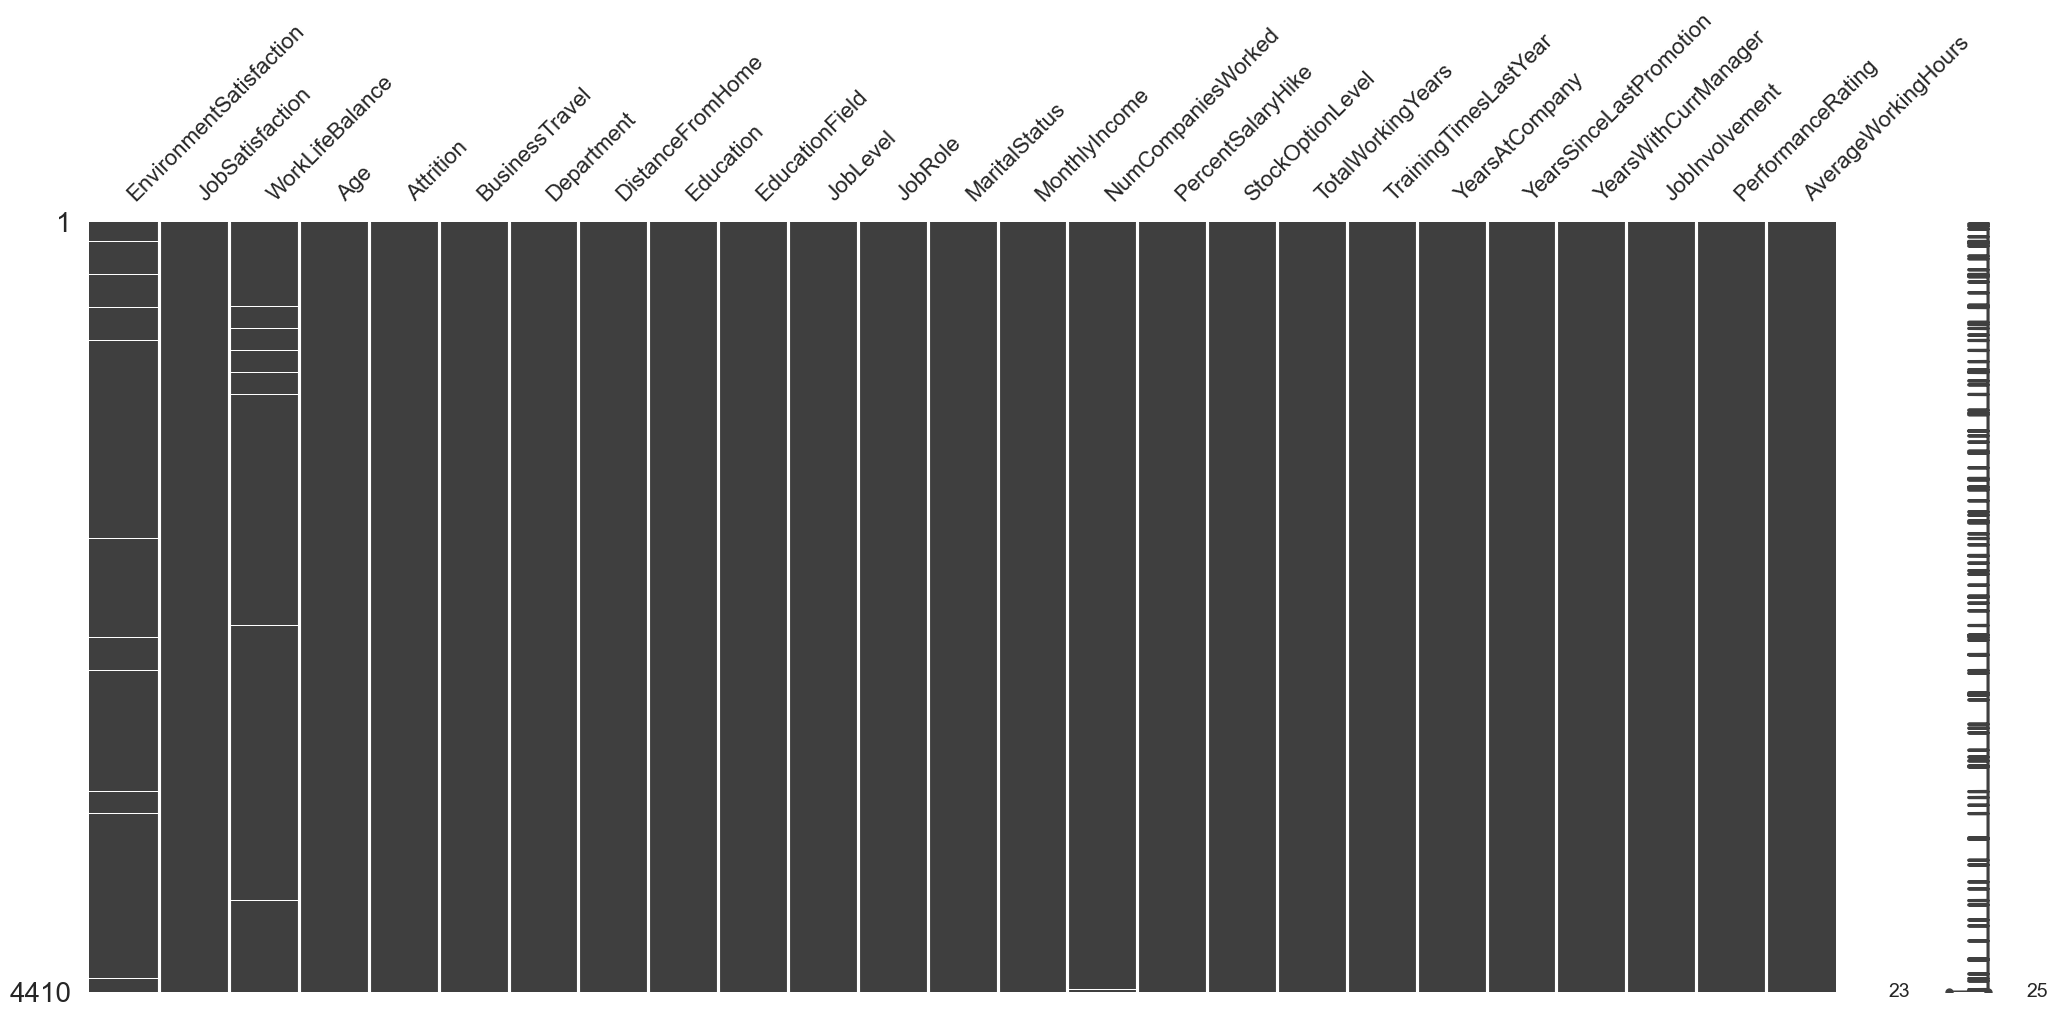

In [10]:
msno.matrix(df_employees)
plt.show()

## 5. Data Preprocessing

### 5.1. Imputing Missing Numerical Values

In [11]:
cols_numerical = df_employees.select_dtypes(include=['int64', 'float64']).columns
df_employees[cols_numerical] = df_employees[cols_numerical].fillna(df_employees[cols_numerical].median())

### 5.2. Imputing Missing Categorical Values

In [12]:
cols_categorical = df_employees.select_dtypes(include=['object']).columns

for col in cols_categorical:
    if df_employees[col].isnull().sum() > 0:
        mode_value = df_employees[col].mode()
        if not mode_value.empty:
            df_employees[col] = df_employees[col].fillna(mode_value[0])
        else:
            df_employees[col] = df_employees[col].fillna('Unknown')

### 5.3. Missing Values Verification

In [13]:
df_employees.isnull().sum()

EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
PercentSalaryHike          0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
JobInvolvement             0
PerformanceRating          0
AverageWorkingHours        0
dtype: int64

### 5.4. Duplicate Removal

In [14]:
count_duplicates = df_employees.duplicated().sum()
print(f"Number of duplicate rows: {count_duplicates}")

if count_duplicates > 0:
    print(f"\nRemoving {count_duplicates} duplicate rows...")
    df_employees = df_employees.drop_duplicates()
    print(f"New data shape after removing duplicates: {df_employees.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### 5.5. Outlier Detection and Treatment

In [15]:
print("Detecting outliers using IQR method...\n")

cols_numerical = df_employees.select_dtypes(include=['int64', 'float64']).columns
indices_outliers = set()

for col in cols_numerical:
    val_q1 = df_employees[col].quantile(0.25)
    val_q3 = df_employees[col].quantile(0.75)
    val_iqr = val_q3 - val_q1
    
    bound_lower = val_q1 - 1.5 * val_iqr
    bound_upper = val_q3 + 1.5 * val_iqr
    
    count_col_outliers = ((df_employees[col] < bound_lower) | (df_employees[col] > bound_upper)).sum()
    if count_col_outliers > 0:
        print(f"{col}: {count_col_outliers} outliers detected (bounds: [{bound_lower:.2f}, {bound_upper:.2f}])")
        indices_outliers.update(df_employees[(df_employees[col] < bound_lower) | (df_employees[col] > bound_upper)].index)

print(f"\nTotal unique rows with outliers: {len(indices_outliers)}")

for col in cols_numerical:
    val_q1 = df_employees[col].quantile(0.25)
    val_q3 = df_employees[col].quantile(0.75)
    val_iqr = val_q3 - val_q1
    
    bound_lower = val_q1 - 1.5 * val_iqr
    bound_upper = val_q3 + 1.5 * val_iqr
    
    df_employees[col] = df_employees[col].clip(lower=bound_lower, upper=bound_upper)

print("Outliers have been capped to their boundary values.")

Detecting outliers using IQR method...

MonthlyIncome: 342 outliers detected (bounds: [-52925.00, 165835.00])
NumCompaniesWorked: 156 outliers detected (bounds: [-3.50, 8.50])
StockOptionLevel: 255 outliers detected (bounds: [-1.50, 2.50])
TotalWorkingYears: 189 outliers detected (bounds: [-7.50, 28.50])
TrainingTimesLastYear: 714 outliers detected (bounds: [0.50, 4.50])
YearsAtCompany: 312 outliers detected (bounds: [-6.00, 18.00])
YearsSinceLastPromotion: 321 outliers detected (bounds: [-4.50, 7.50])
YearsWithCurrManager: 42 outliers detected (bounds: [-5.50, 14.50])
PerformanceRating: 678 outliers detected (bounds: [3.00, 3.00])
AverageWorkingHours: 38 outliers detected (bounds: [4.13, 10.91])

Total unique rows with outliers: 2139
Outliers have been capped to their boundary values.


### 5.6. Removal of Invariant Features

In [16]:
cols_invariant = [col for col in df_employees.columns 
                      if df_employees[col].nunique() == 1]

print(f"Constant columns (only 1 unique value) found: {cols_invariant}")

if cols_invariant:
    print(f"\nRemoving constant columns: {cols_invariant}")
    df_employees = df_employees.drop(columns=cols_invariant)
    print(f"New shape after removing constant columns: {df_employees.shape}")
else:
    print("No constant columns found.")

Constant columns (only 1 unique value) found: ['PerformanceRating']

Removing constant columns: ['PerformanceRating']
New shape after removing constant columns: (4410, 24)


### 5.7. Encoding Categorical Features

In [17]:
cols_categorical = df_employees.select_dtypes(include=['object']).columns.tolist()
cols_numerical = df_employees.select_dtypes(include=['int64', 'float64']).columns.tolist()

if cols_categorical:
    print(f"Applying One-Hot Encoding")
    df_encoded = pd.get_dummies(df_employees,
                                columns=cols_categorical,
                                drop_first=True)
    print(f"Shape after encoding: {df_encoded.shape}")
else:
    df_encoded = df_employees.copy()
print(cols_categorical)
print("One-Hot Encoding completed succesfuly.\n")

col_target_encoded = "Attrition_Yes"

if col_target_encoded not in df_encoded.columns:
    print(f"ERROR: '{col_target_encoded}' not found. Did you drop_first=True?")
    print("Available columns", df_encoded.columns[:5])
else:
    y = df_encoded[col_target_encoded]

    df_features_raw = df_encoded.drop(columns=[col_target_encoded], errors="ignore")
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_features_raw)

    X = pd.DataFrame(features_scaled, columns=df_features_raw.columns)

    print("-" * 30)
    print("Feature shape (X):", X.shape)
    print("Target shape (y):", y.shape)
    print("-" * 30)

Applying One-Hot Encoding
Shape after encoding: (4410, 38)
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
One-Hot Encoding completed succesfuly.

------------------------------
Feature shape (X): (4410, 37)
Target shape (y): (4410,)
------------------------------


### 5.8. Final Data Preparation Validation

In [18]:
print("="*60)
print("FINAL DATA PREPARATION VALIDATION REPORT (Checking variable 'X')")
print("="*60)

print(f"\n1. DIMENSION CHECK")
print(f"   Expected columns: 37")
print(f"   Actual columns:   {X.shape[1]}")

if X.shape[1] == 37:
    print("PASS: Dimension check passed")
else:
    print("FAIL: You might not be using the right variable (Leakage or missing columns)")

print(f"\n2. DATA TYPE CHECK")
cols_non_float = X.select_dtypes(exclude=['float64', 'float32']).columns.tolist()

if len(cols_non_float) == 0:
    print("PASS: All columns are scaled floats")
else:
    print(f"FAIL: Non-float columns found: {cols_non_float}")

print(f"\n3. LEAKAGE CHECK")
cols_suspect = ['Attrition', 'Attrition_Yes']
cols_found = [col for col in cols_suspect if col in X.columns]

if len(cols_found) == 0:
    print("PASS: Leakage check passed (Target/IDs removed)")
else:
    print(f"FAIL: Leakage detected, suspicious columns: {cols_found}")

print(f"\n4. SCALING CHECK")
val_mean_global = X.mean().mean()
val_std_global = X.std().mean()

print(f"   Mean of features: {val_mean_global:.4f} (Should be ~0)")
print(f"   Std of features:  {val_std_global:.4f} (Should be ~1)")

if -0.1 < val_mean_global < 0.1 and 0.9 < val_std_global < 1.1:
    print("PASS: Data is properly standardized")
else:
    print("WARNING: Data might not be scaled correctly")

print("="*60)

FINAL DATA PREPARATION VALIDATION REPORT (Checking variable 'X')

1. DIMENSION CHECK
   Expected columns: 37
   Actual columns:   37
PASS: Dimension check passed

2. DATA TYPE CHECK
PASS: All columns are scaled floats

3. LEAKAGE CHECK
PASS: Leakage check passed (Target/IDs removed)

4. SCALING CHECK
   Mean of features: -0.0000 (Should be ~0)
   Std of features:  1.0001 (Should be ~1)
PASS: Data is properly standardized


## 6. Exploratory Visual Analysis (Post-Processing)

### 6.1. Numerical Feature Distributions

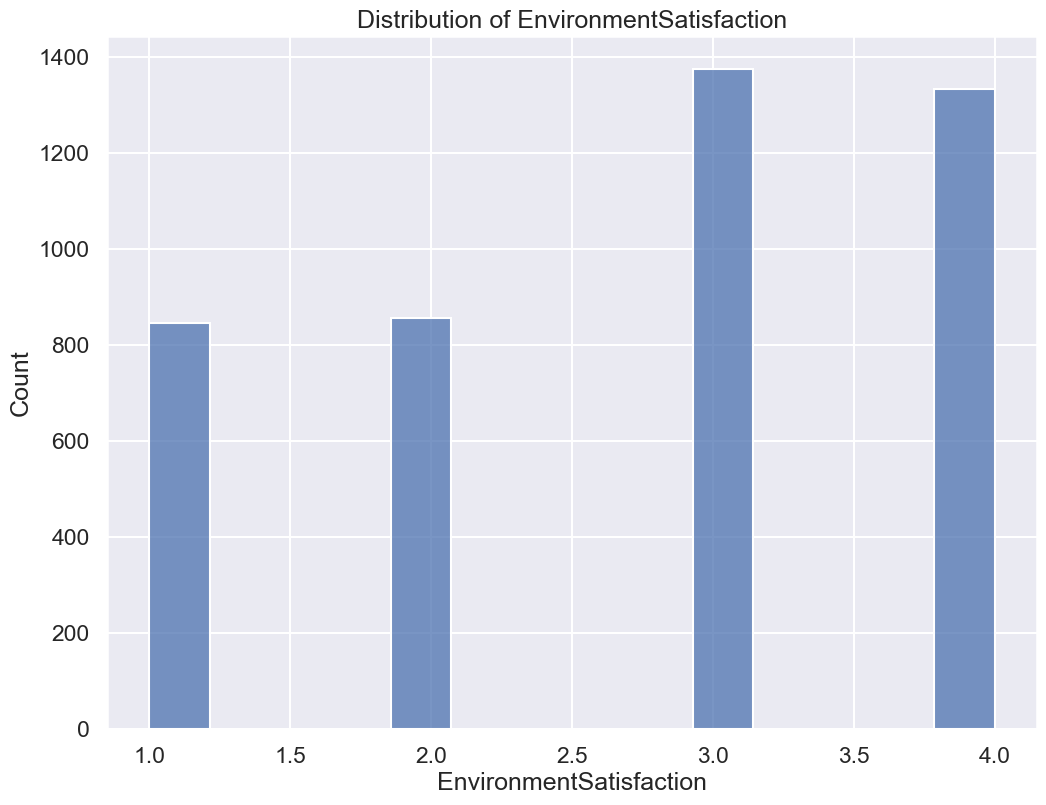

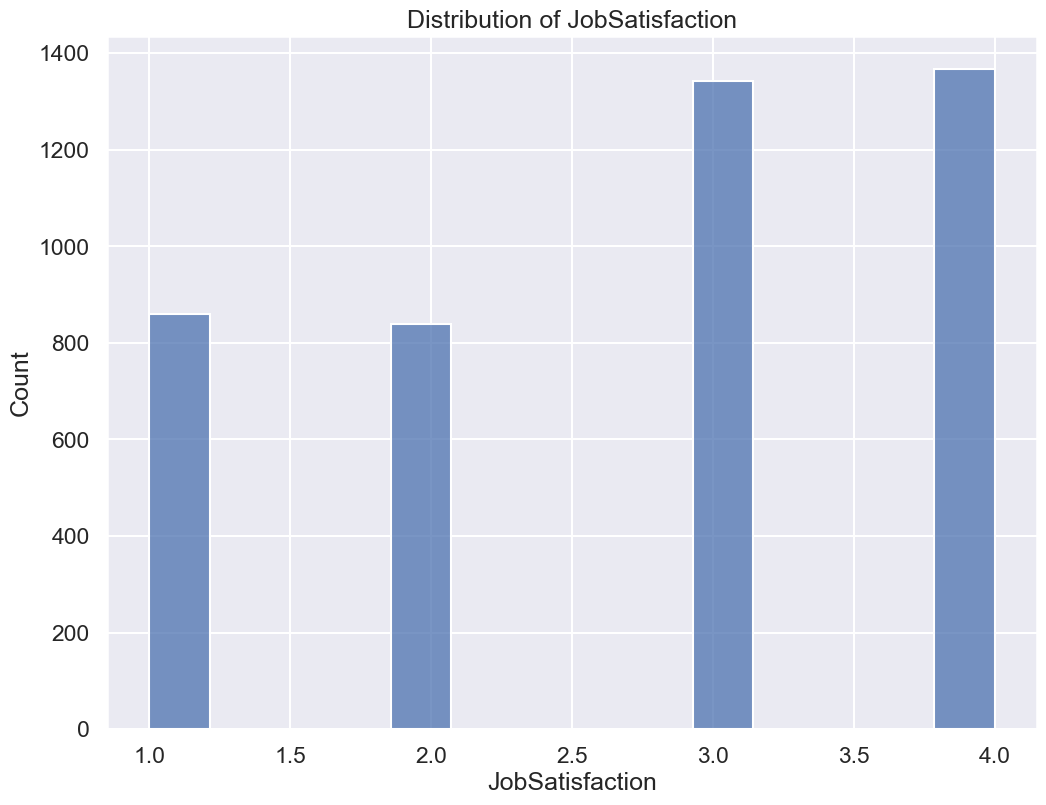

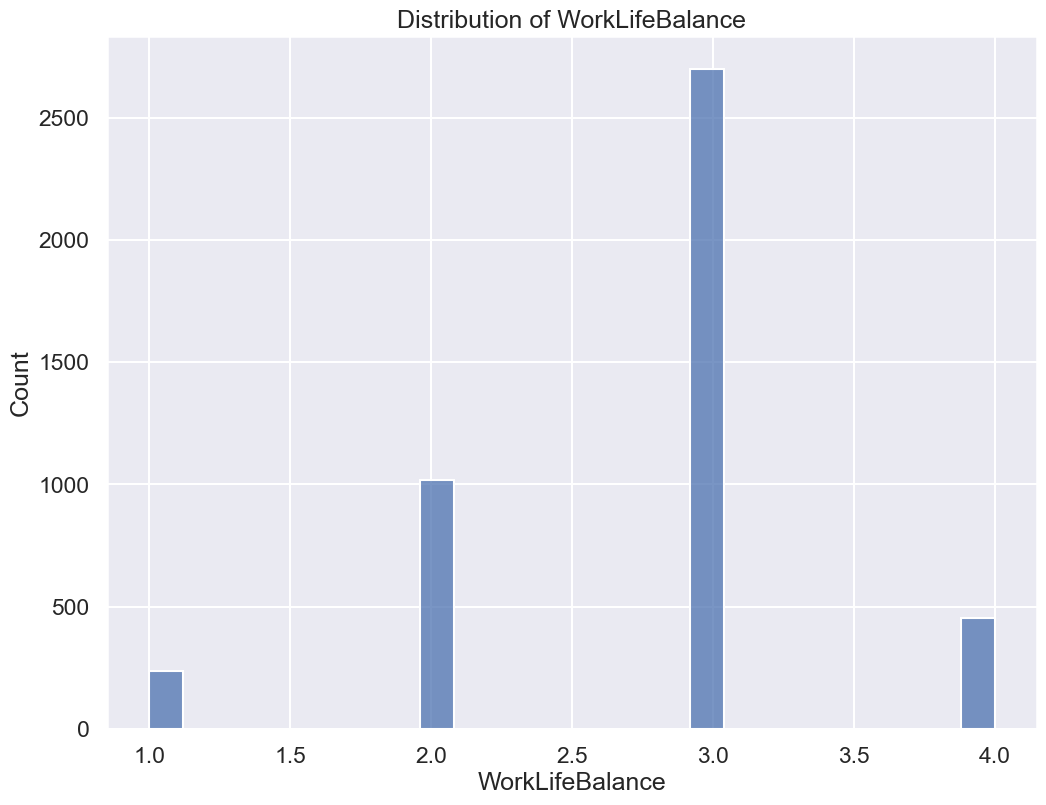

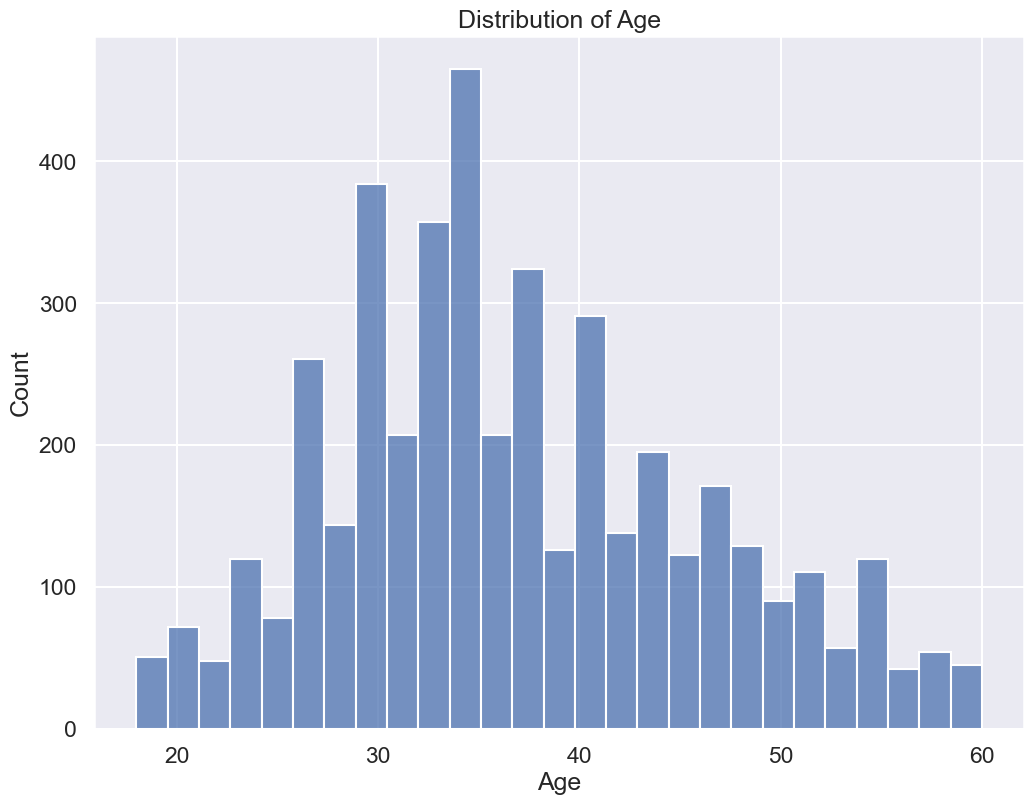

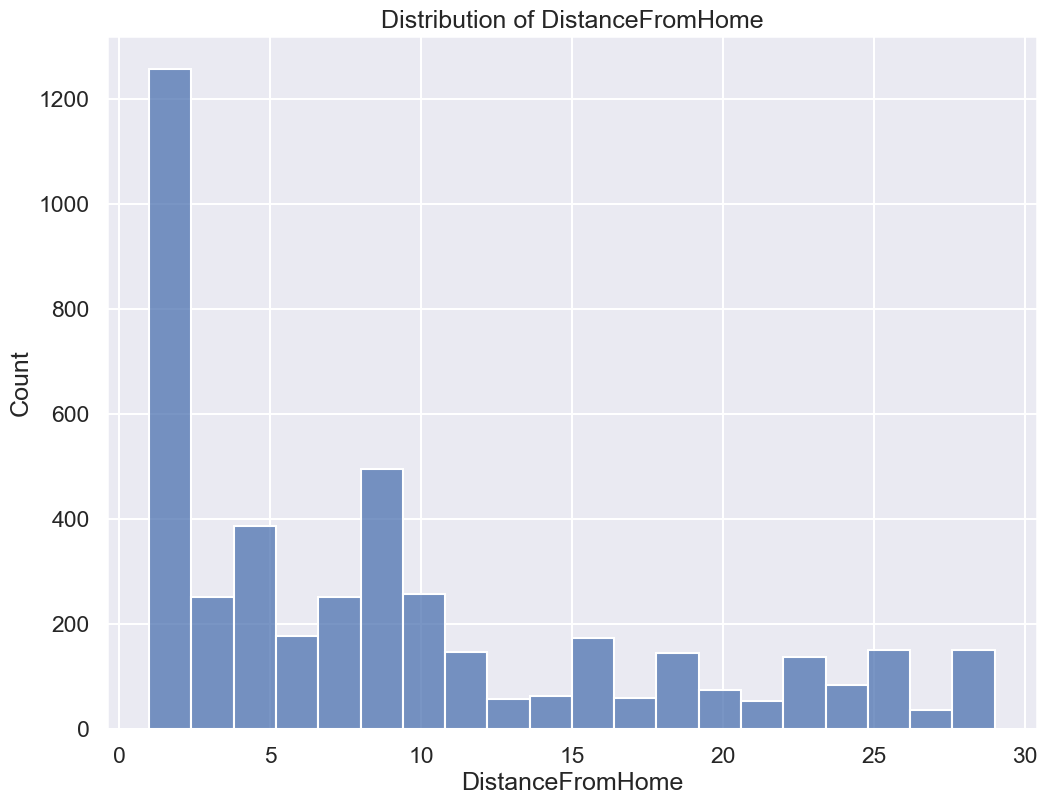

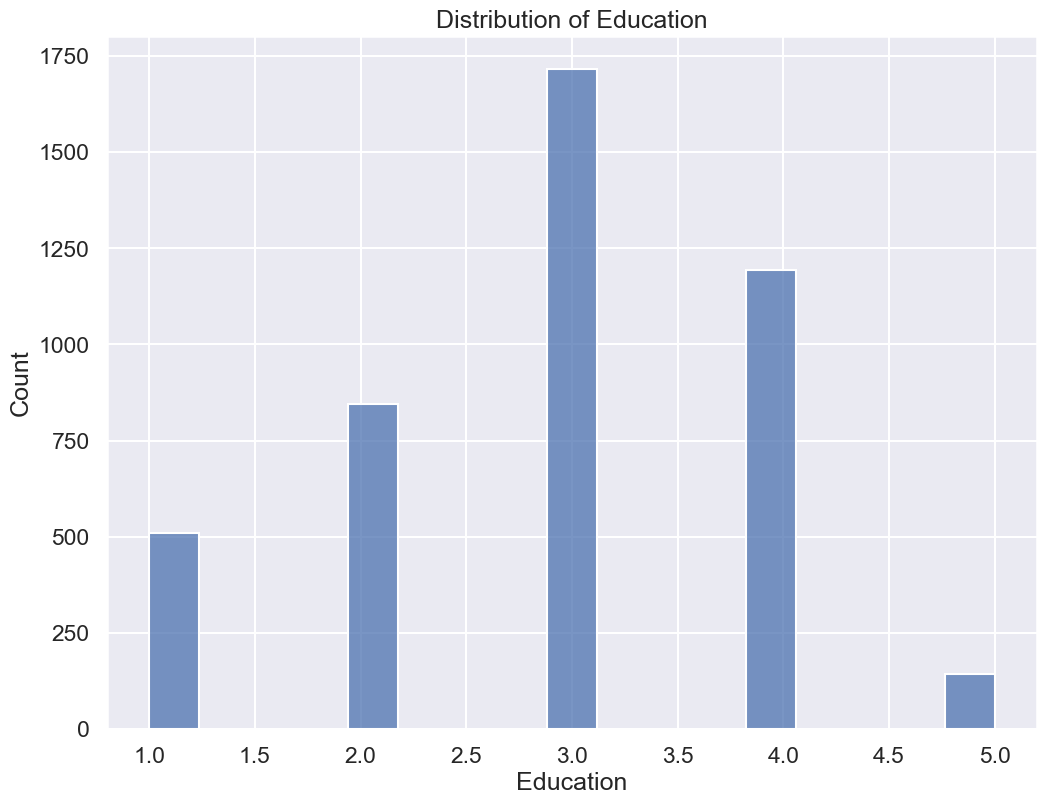

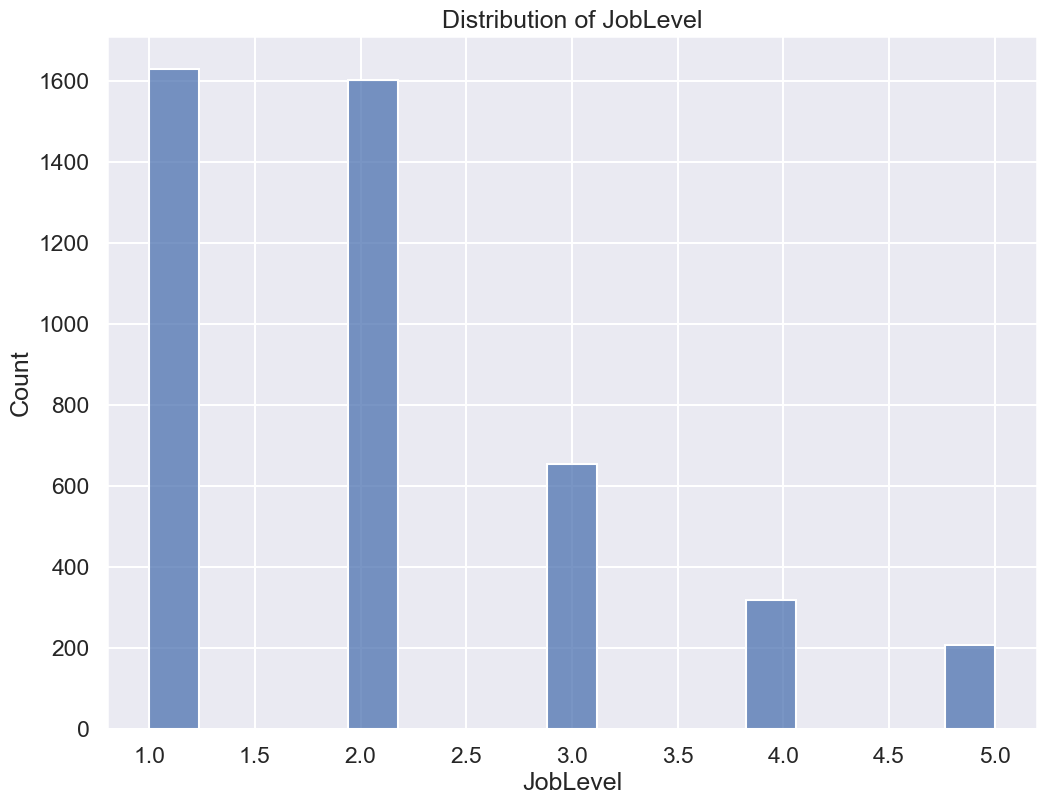

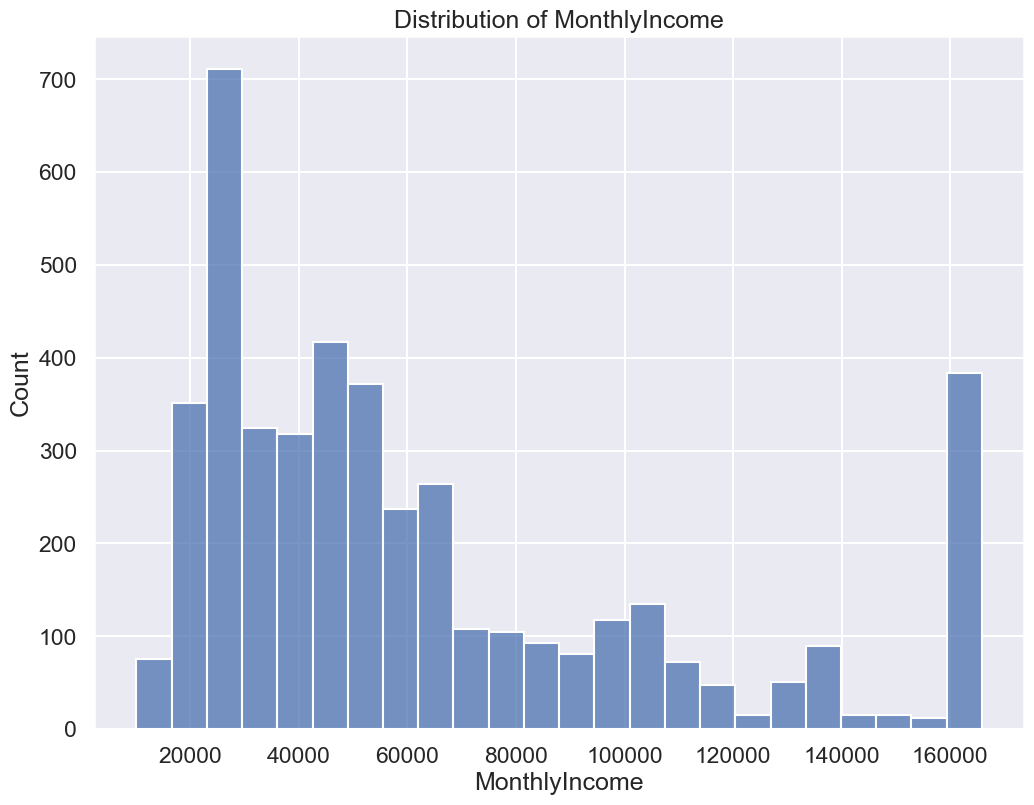

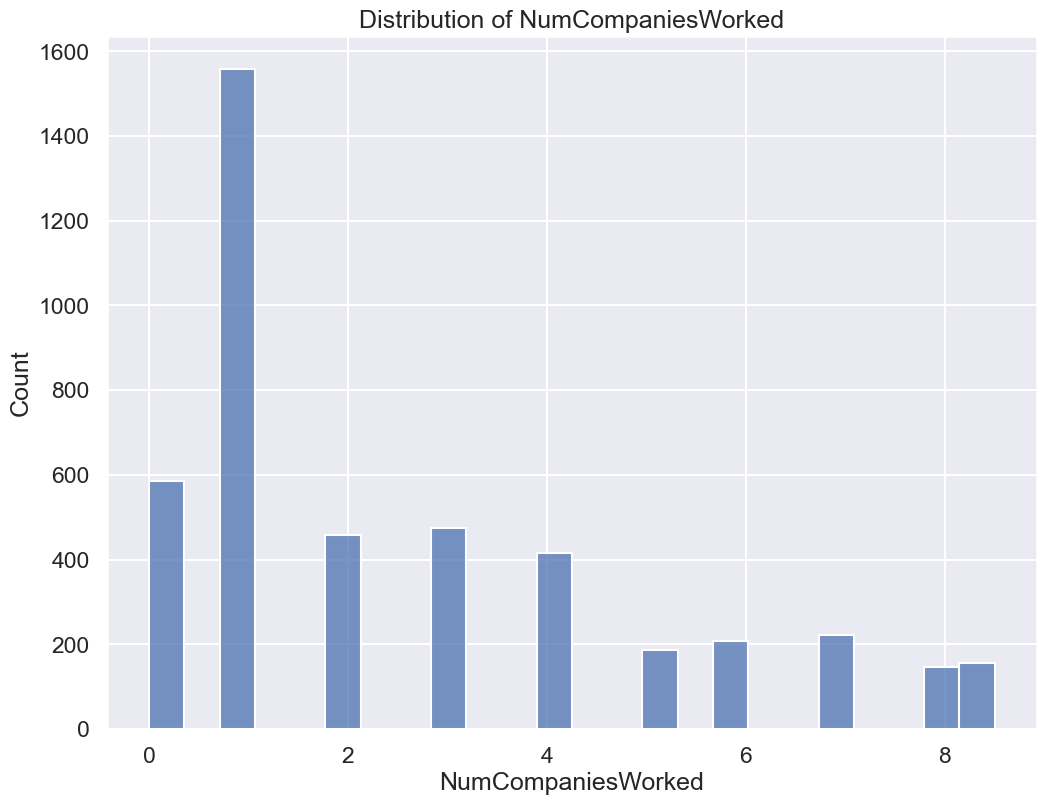

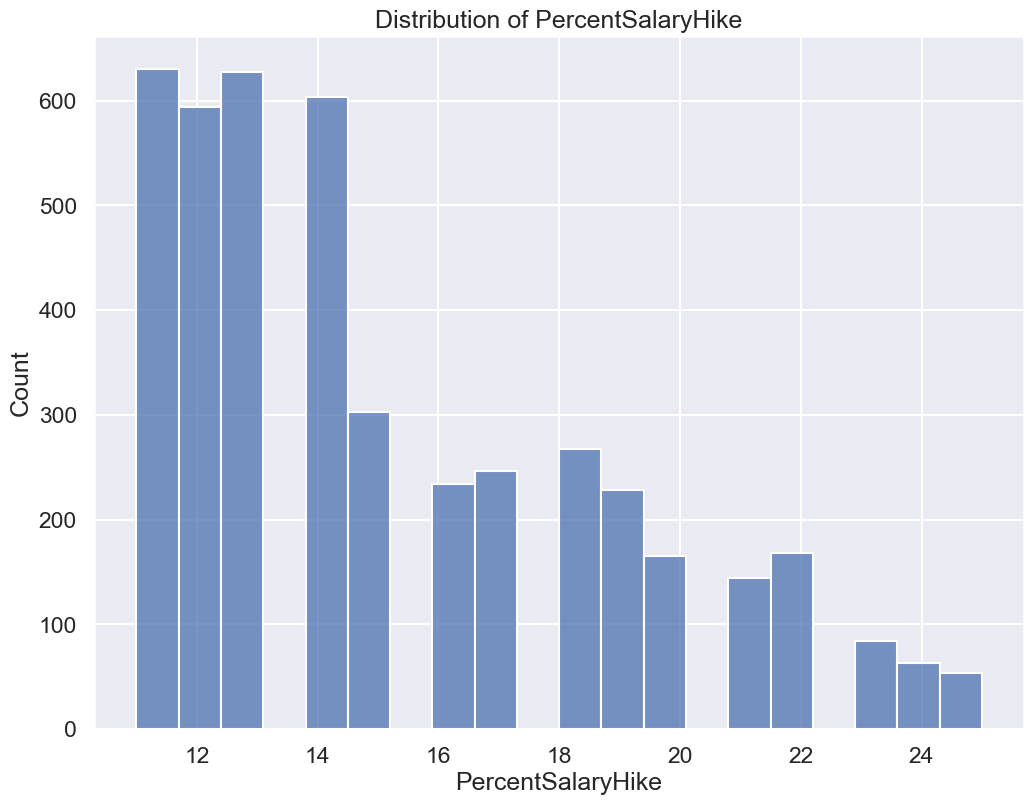

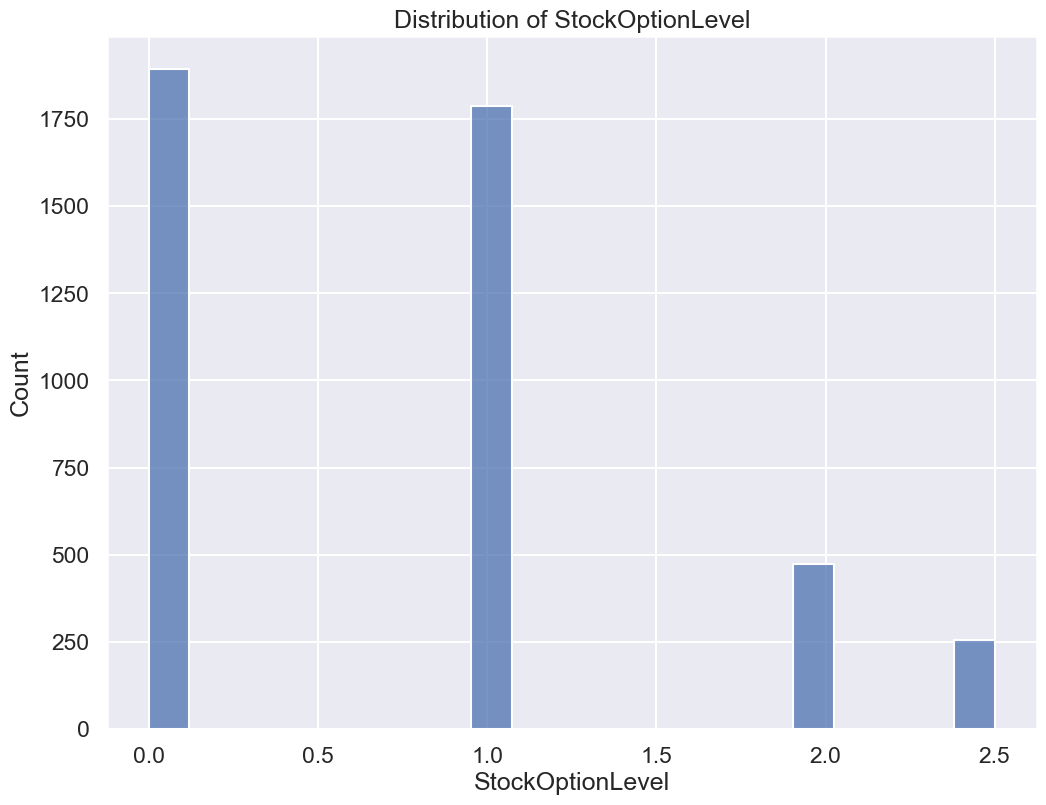

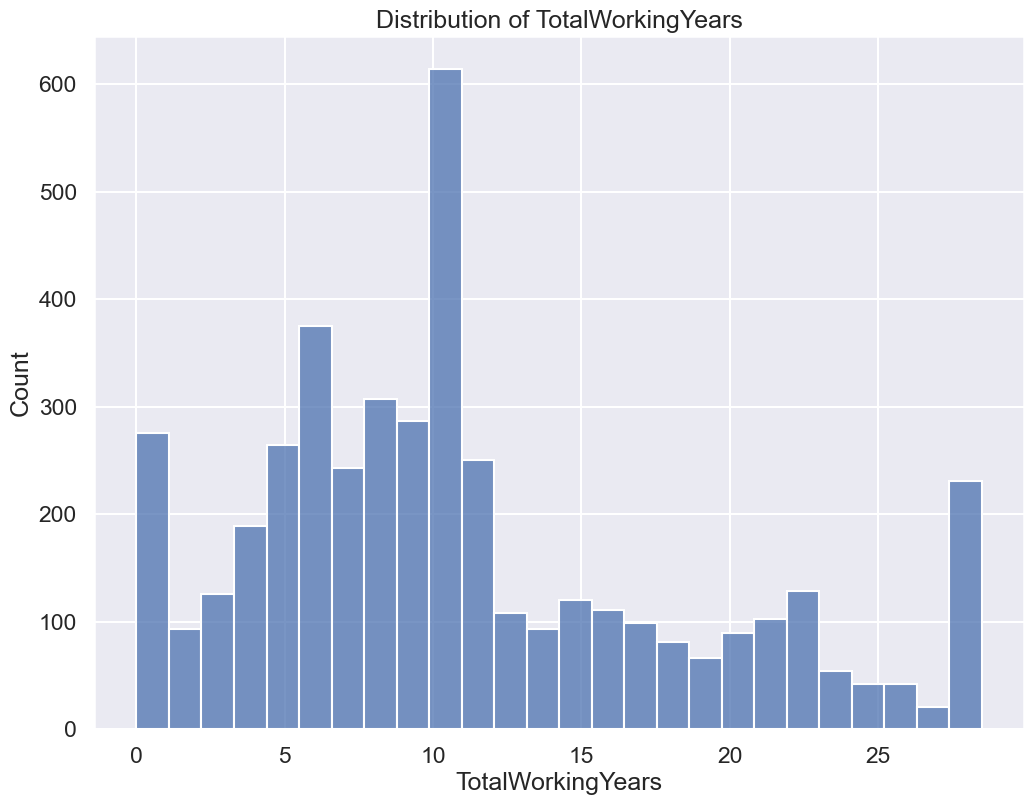

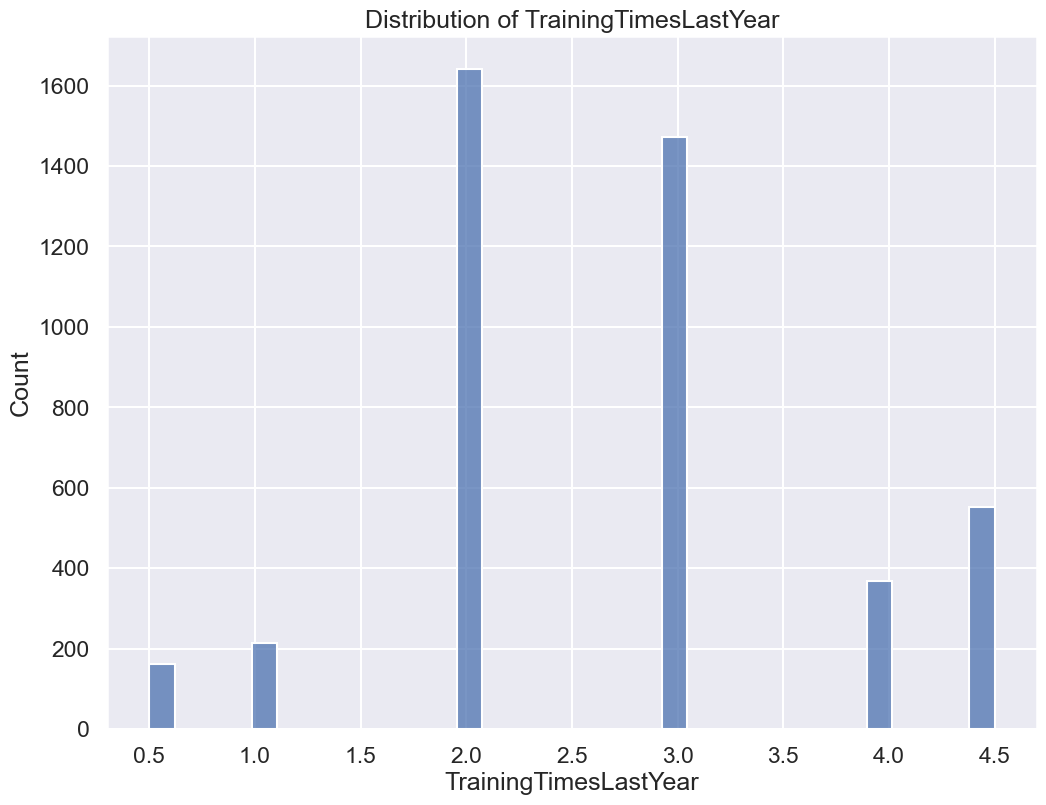

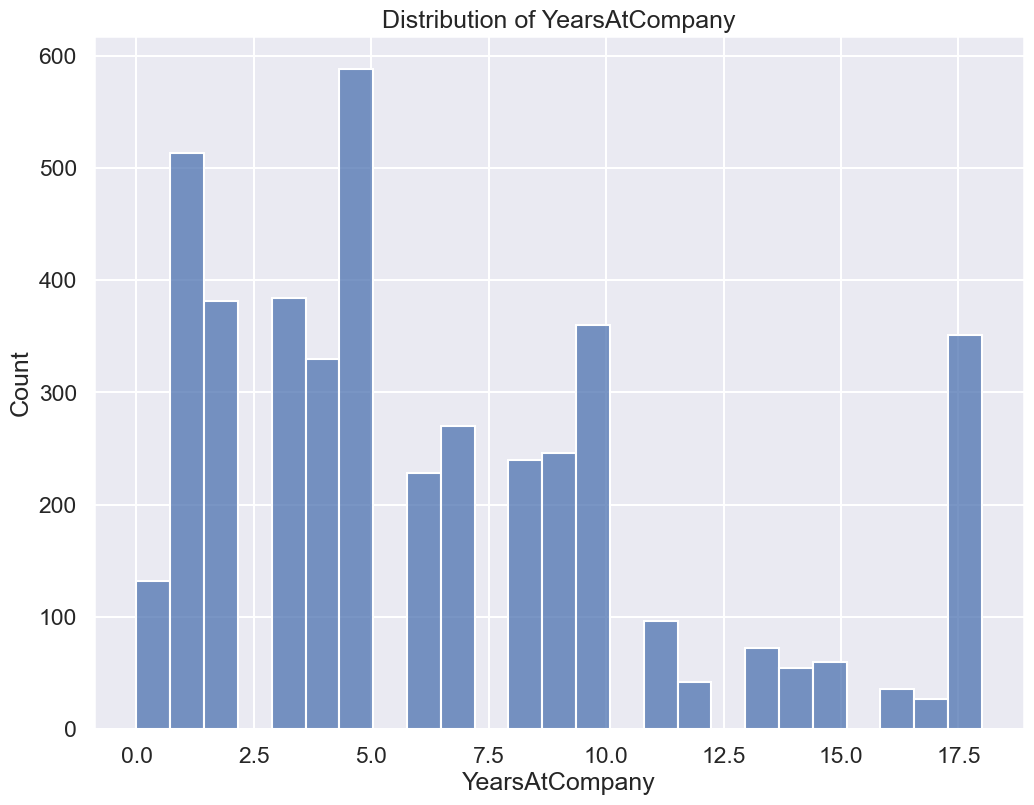

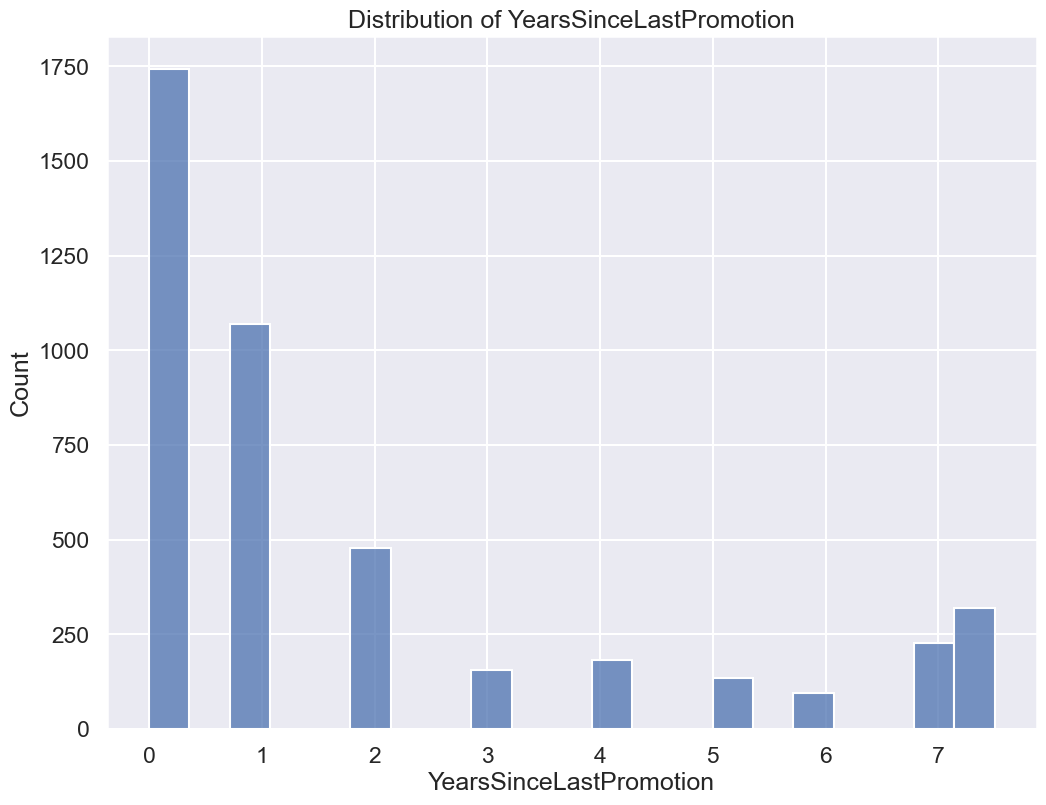

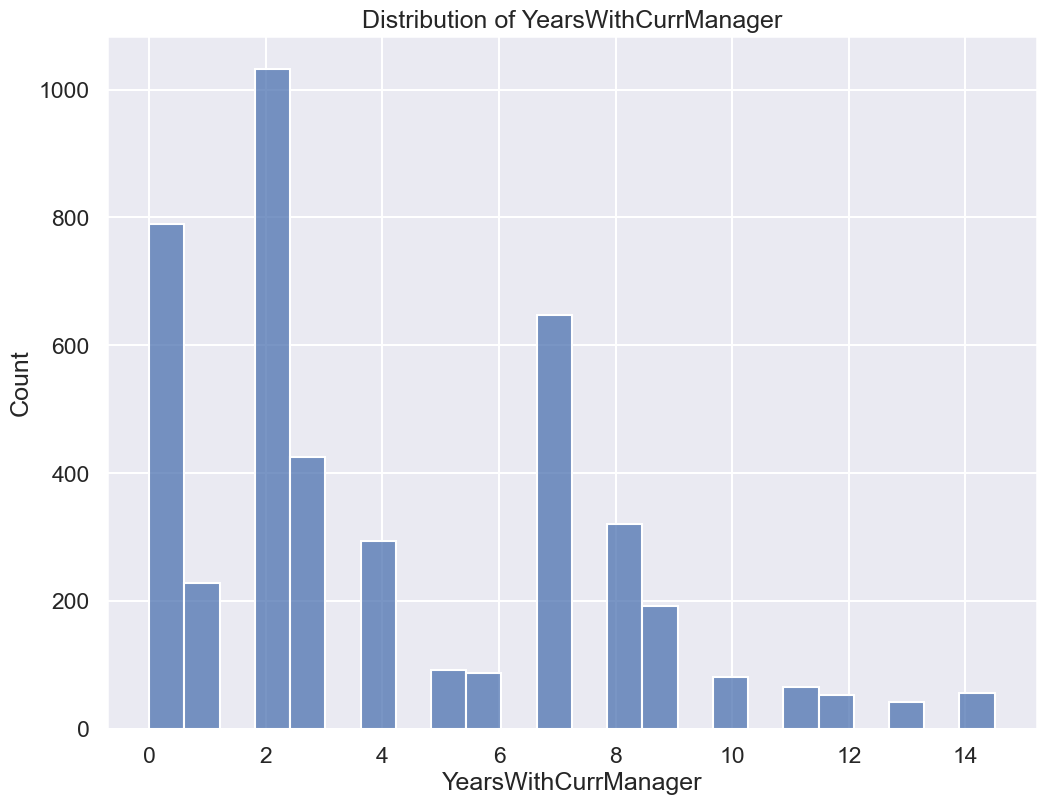

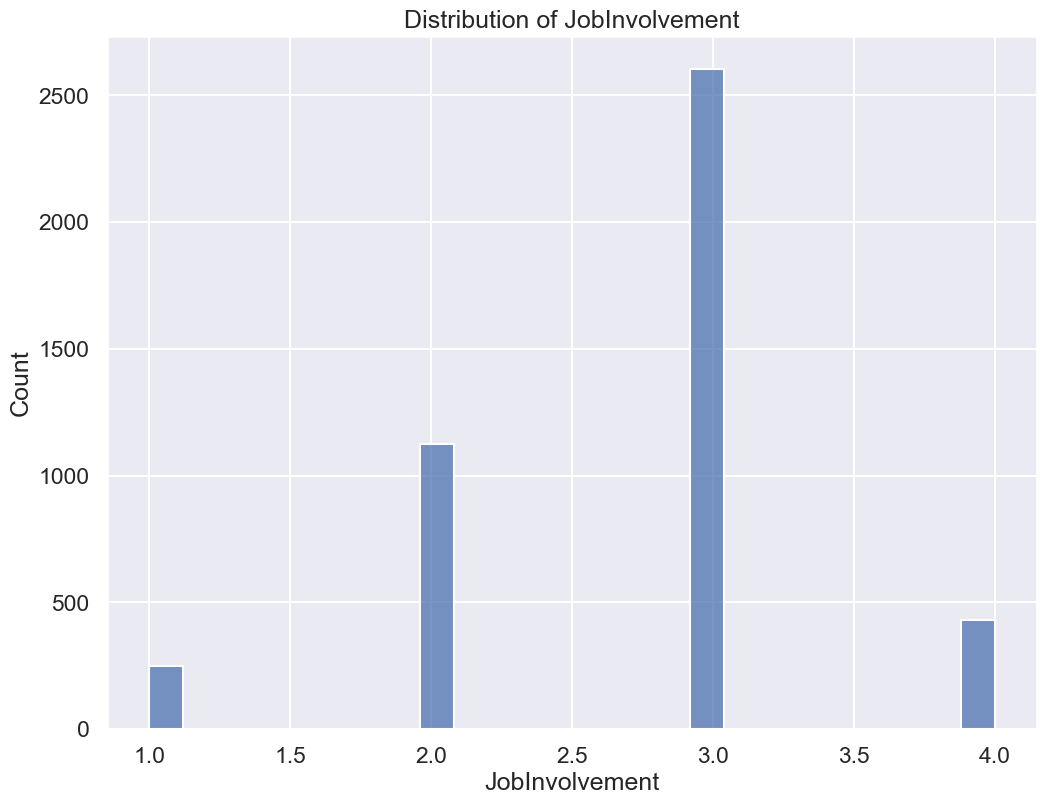

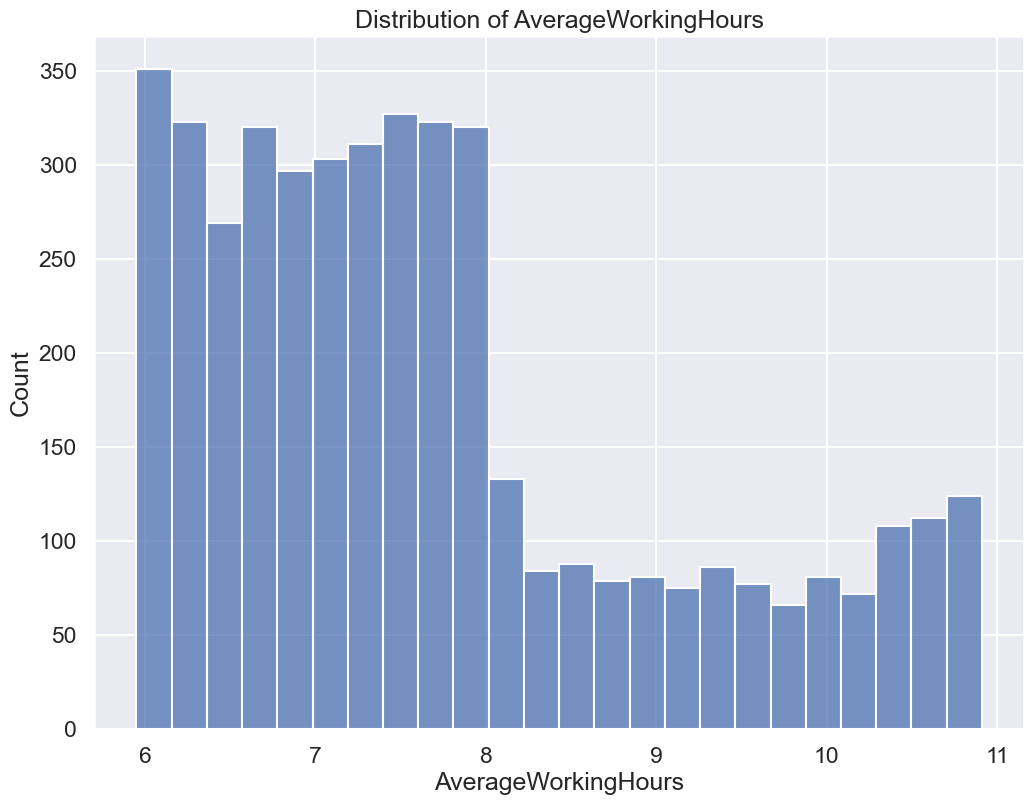

In [19]:
for col in cols_numerical:
    sns.histplot(data=df_employees, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

### 6.2. Categorical Feature Visualization

<Axes: xlabel='Attrition', ylabel='count'>

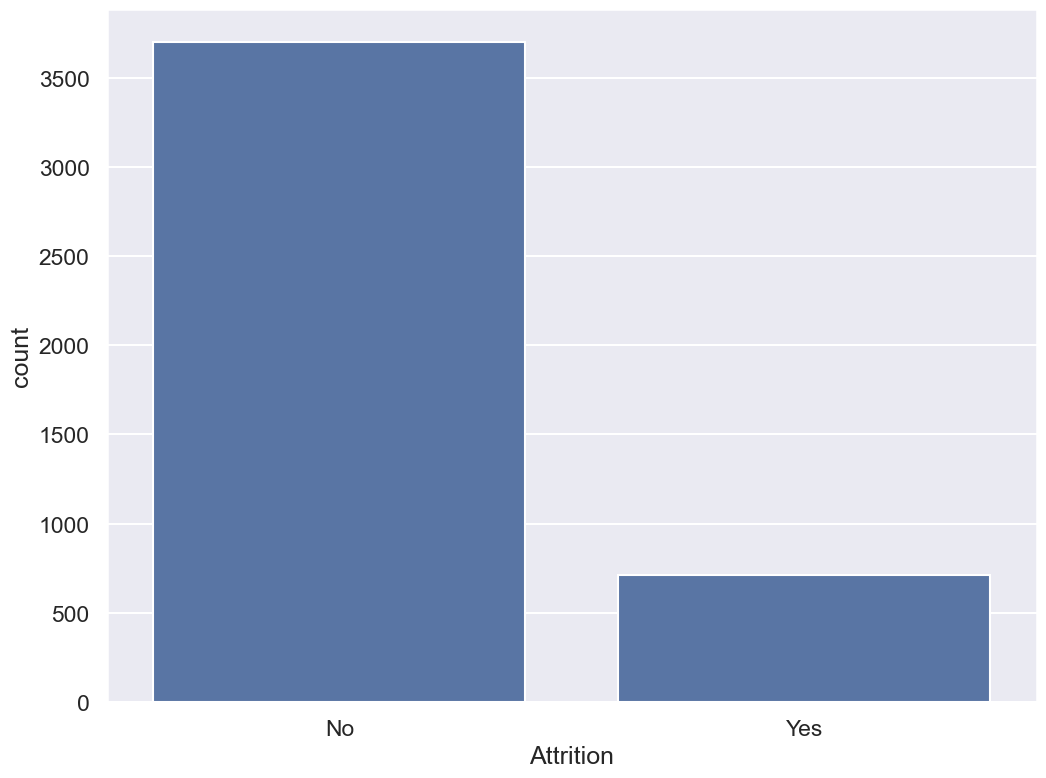

In [20]:
sns.countplot(x=df_employees[cols_categorical[0]])

### 6.3. Feature Type Identification

In [21]:
cols_numerical = df_employees.select_dtypes(include=['float64', 'int64']).columns
cols_categorical = df_employees.select_dtypes(include=["object"]).columns
print('numerical columns', cols_numerical)
print('categorical columns', cols_categorical)

numerical columns Index(['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age',
       'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
       'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement',
       'AverageWorkingHours'],
      dtype='object')
categorical columns Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField',
       'JobRole', 'MaritalStatus'],
      dtype='object')


### 6.4. Pairwise Relationships

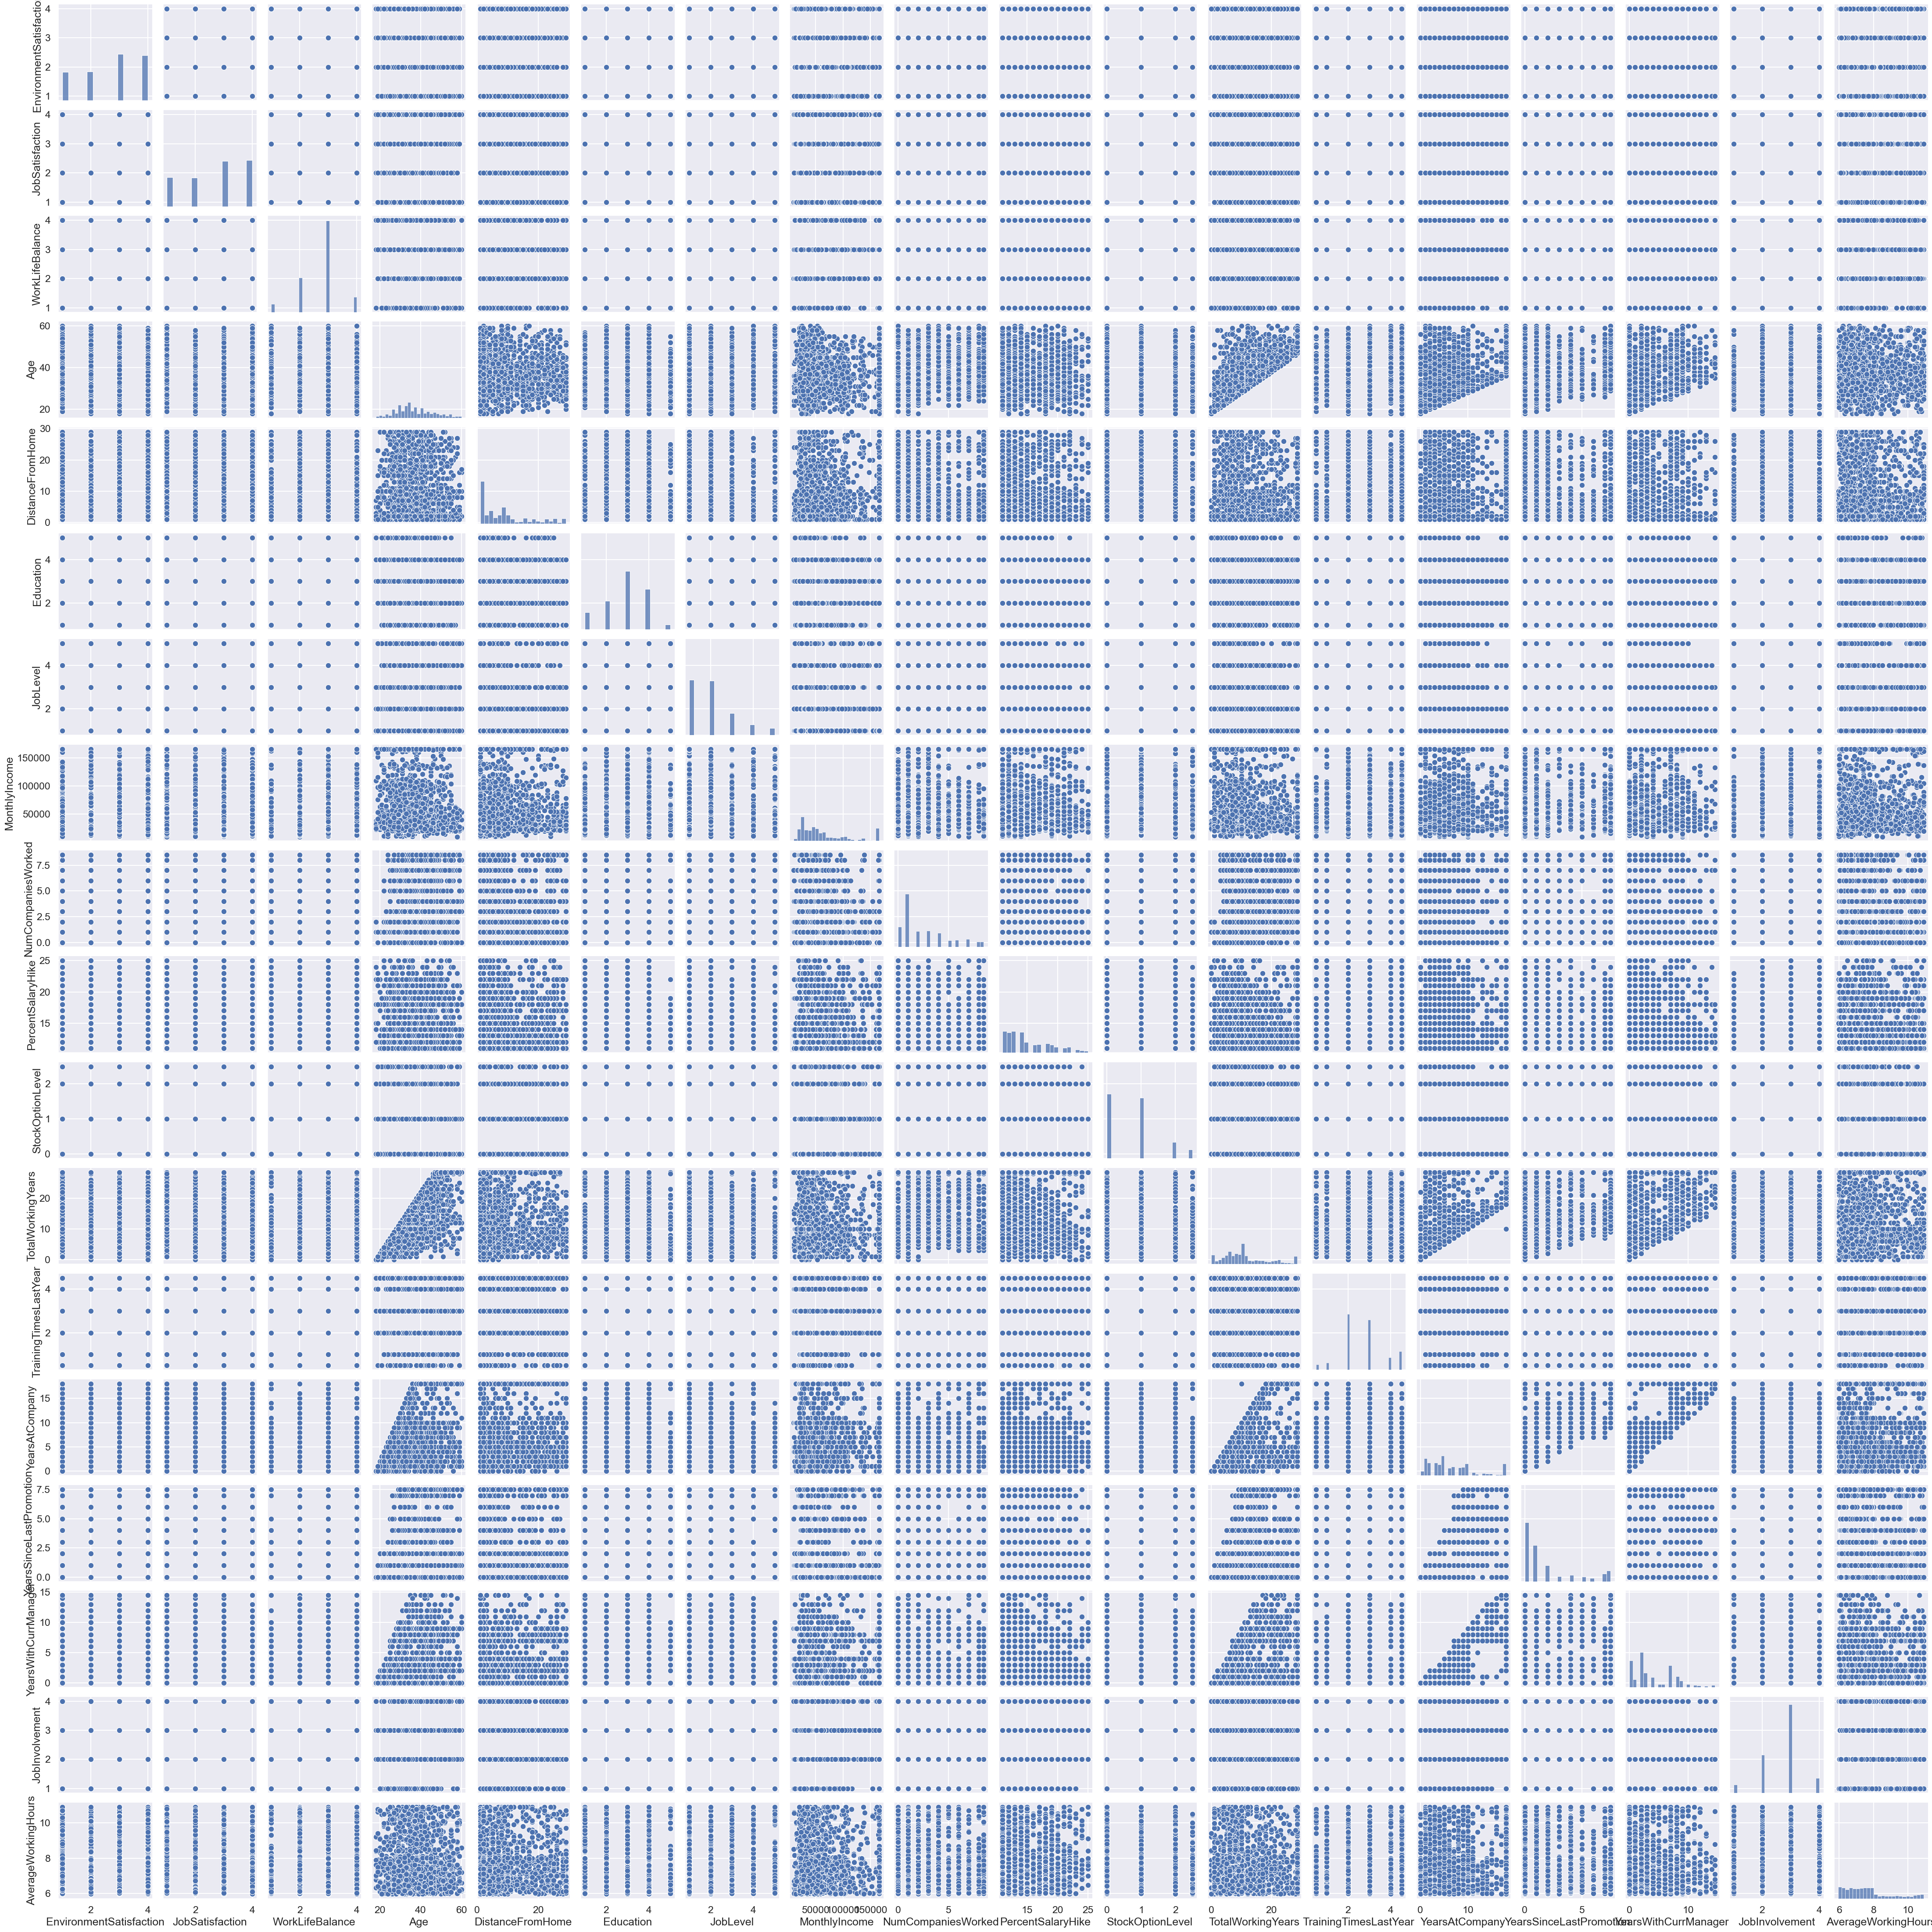

In [22]:
sns.pairplot(df_employees)
plt.show()

### 6.5. Bivariate Analysis: Categorical vs Numerical

C:\Users\theoc\AppData\Local\Temp\ipykernel_36148\252387268.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


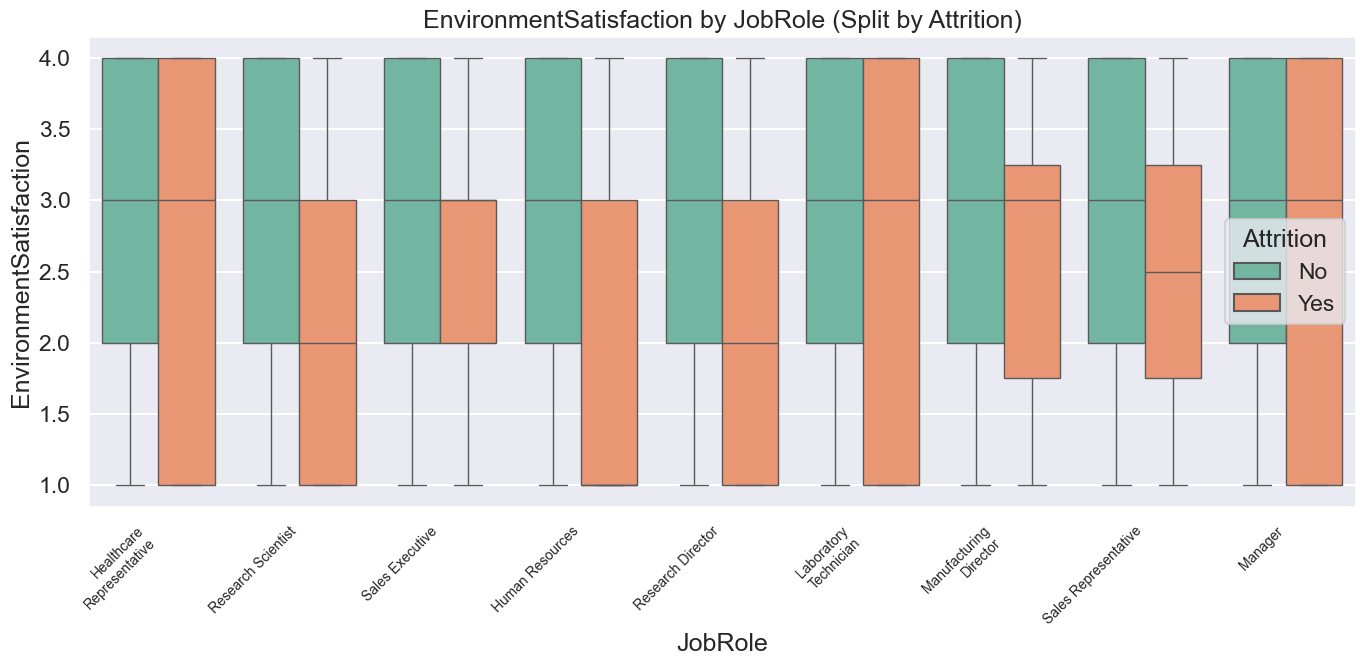

C:\Users\theoc\AppData\Local\Temp\ipykernel_36148\252387268.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


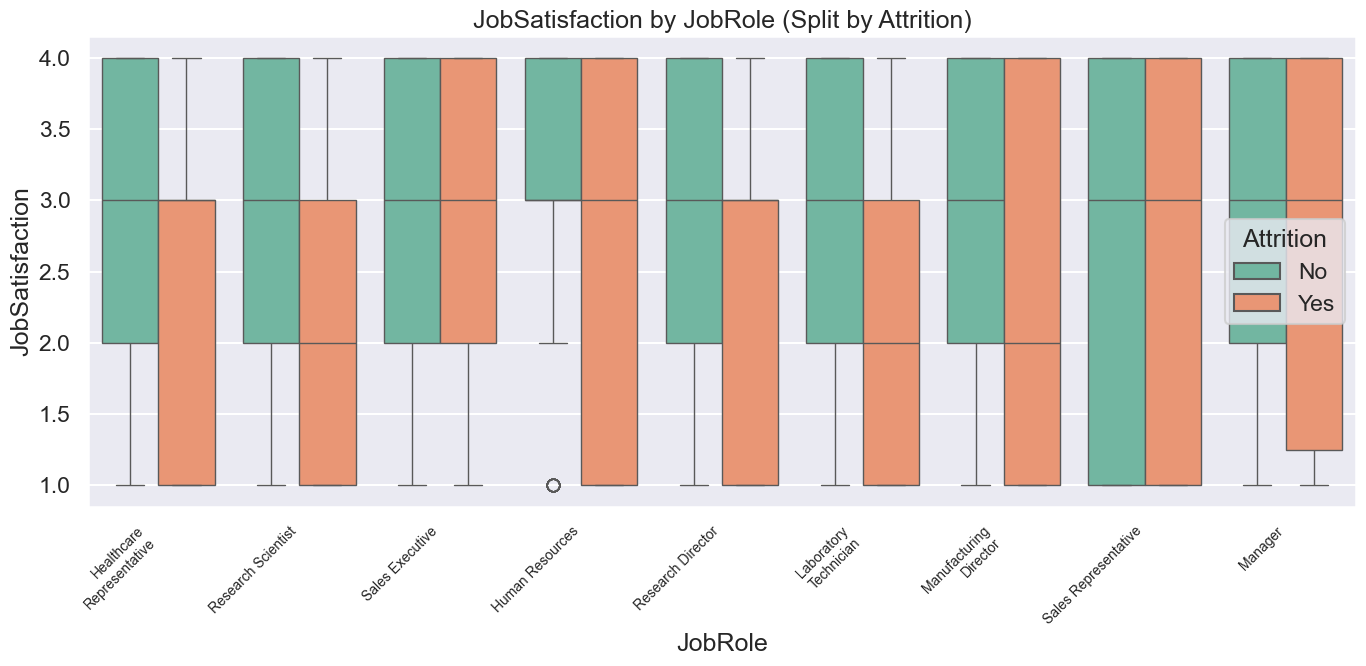

C:\Users\theoc\AppData\Local\Temp\ipykernel_36148\252387268.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


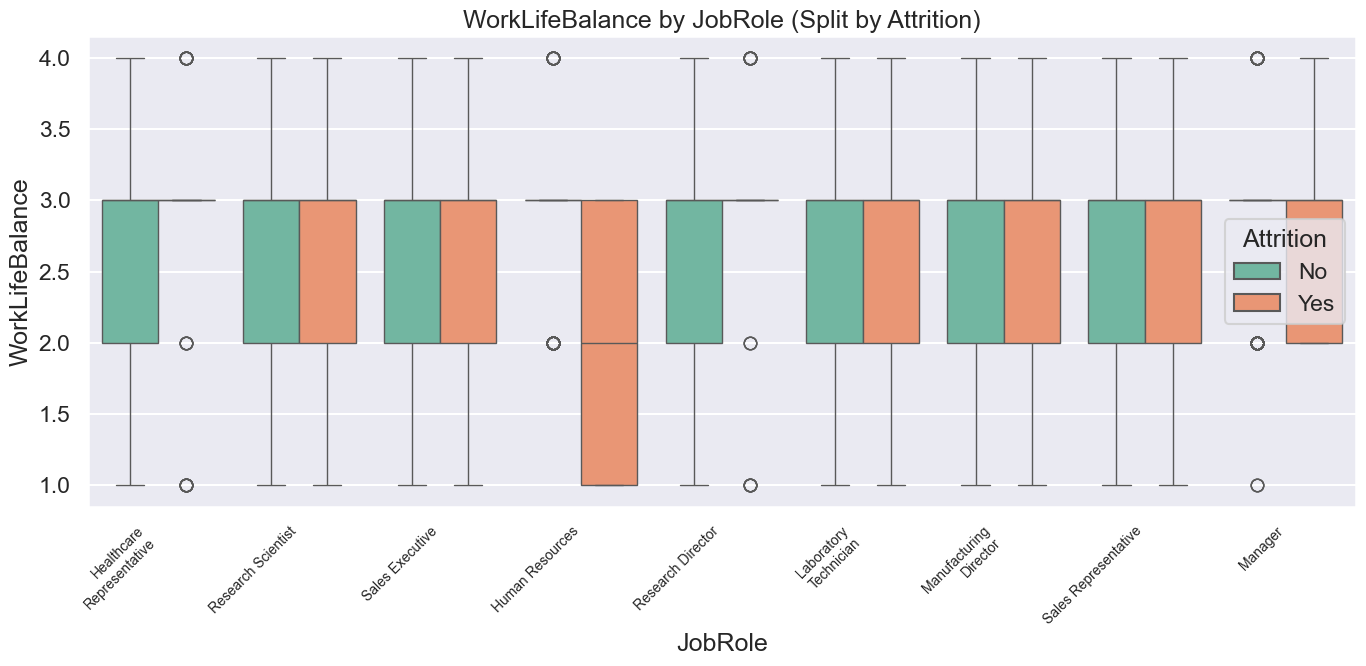

C:\Users\theoc\AppData\Local\Temp\ipykernel_36148\252387268.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


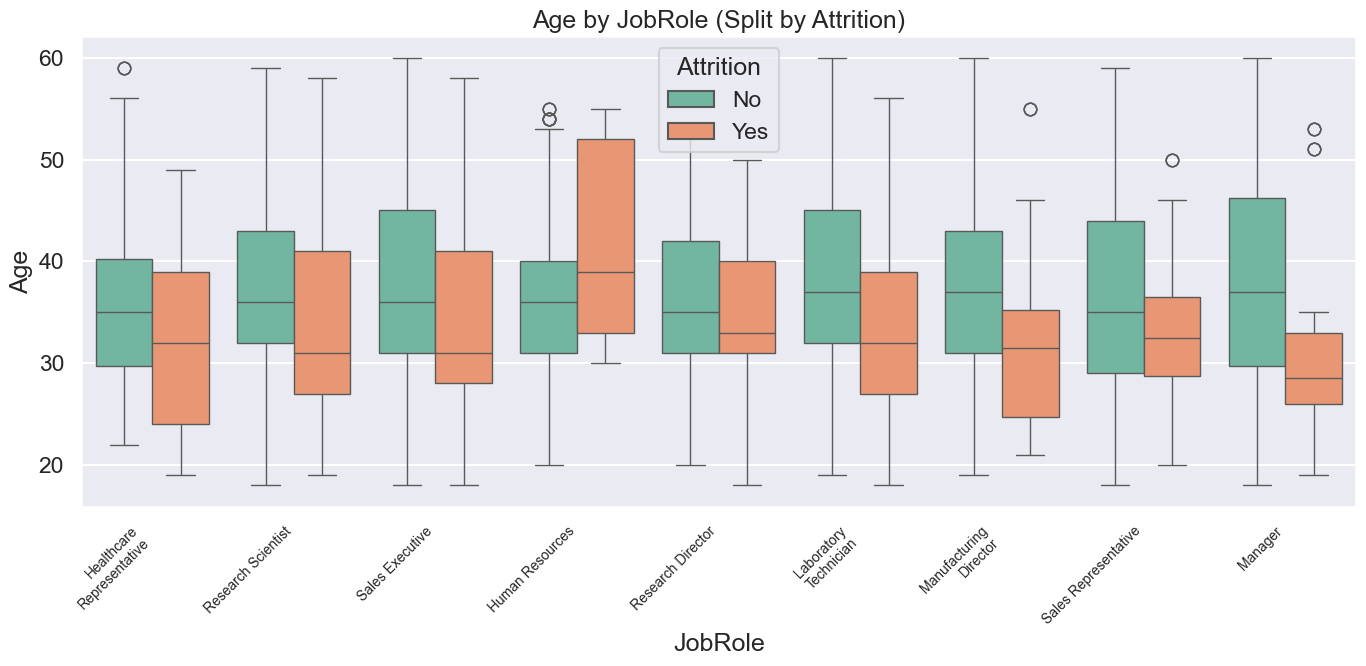

C:\Users\theoc\AppData\Local\Temp\ipykernel_36148\252387268.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


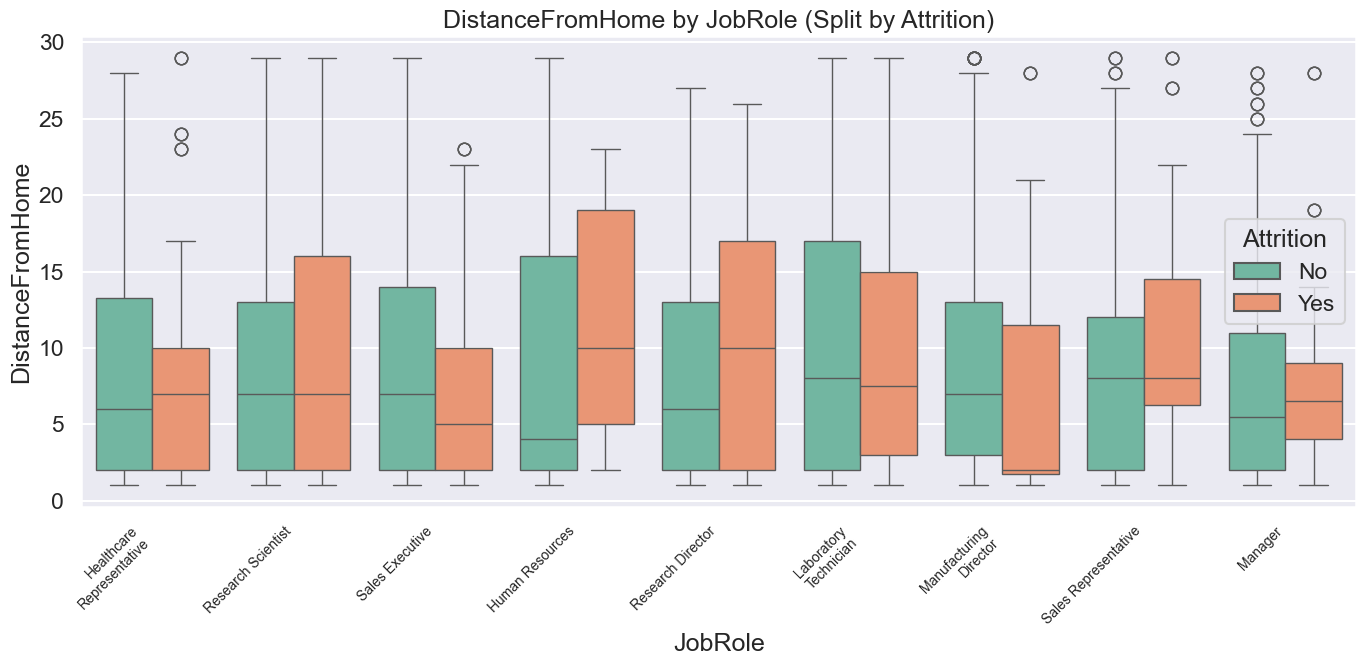

In [23]:
import textwrap

cols_of_interest = [
    'MonthlyIncome',
    'Age',
    'TotalWorkingYears',
    'YearsAtCompany',
    'DistanceFromHome'
]

col_category = 'JobRole'
col_target_raw = 'Attrition'

count_categories = df_employees[col_category].nunique()

for col_metric in cols_numerical[:5]:
    plt.figure(figsize=(14, 7))
    if count_categories > 10:
        ax = sns.boxplot(
            data=df_employees,
            y=col_category,
            x=col_metric,
            hue=col_target_raw,
            palette="Set2"
        )
        plt.title(f'{col_metric} by {col_category} (Split by {col_target_raw})')
        labels = [textwrap.fill(t.get_text(), 30) for t in ax.get_yticklabels()]
        ax.set_yticklabels(labels, fontsize=10)
    else:
        ax = sns.boxplot(
            data=df_employees,
            x=col_category,
            y=col_metric,
            hue=col_target_raw,
            palette="Set2"
        )
        plt.title(f'{col_metric} by {col_category} (Split by {col_target_raw})')
        labels = [textwrap.fill(t.get_text(), 20) for t in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()

### 6.6. Target Variable Correlation Analysis

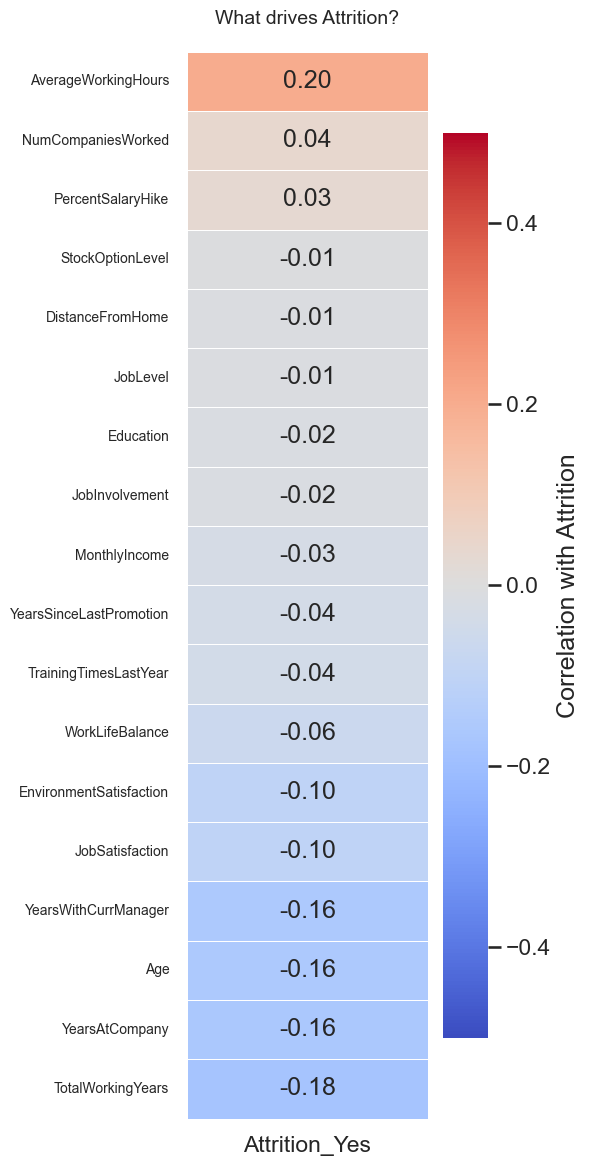

In [24]:
import numpy as np

df_viz = df_employees.copy()

if 'Attrition' in df_viz.columns and df_viz['Attrition'].dtype == 'object':
    df_viz['Attrition_Yes'] = df_viz['Attrition'].map({'Yes': 1, 'No': 0})
    col_target_numeric = 'Attrition_Yes'
else:
    col_target_numeric = 'Attrition'

if hasattr(cols_numerical, 'tolist'):
    list_cols_check = list(cols_numerical.tolist())
else:
    list_cols_check = list(cols_numerical)

list_cols_check = list_cols_check + [col_target_numeric]

df_correlation = df_viz[list_cols_check].corr()[[col_target_numeric]].sort_values(by=col_target_numeric, ascending=False)

df_correlation = df_correlation.drop(col_target_numeric)

plt.figure(figsize=(6, 12))

sns.heatmap(
    df_correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-0.5,
    vmax=0.5,
    center=0,
    fmt='.2f',
    cbar_kws={'label': 'Correlation with Attrition'},
    linewidths=0.5,
    linecolor='white'
)
plt.title('What drives Attrition?', fontsize=14, pad=20)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Machine Learning Modeling

### 7.1. Pre-Modeling Data Verification

In [25]:
print("Target variable distribution:")
print(y.value_counts())
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nData ready for model building!")

Target variable distribution:
Attrition_Yes
False    3699
True      711
Name: count, dtype: int64

Features shape: (4410, 37)
Target shape: (4410,)

Data ready for model building!


### 7.2. Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTesting set target distribution:")
print(y_test.value_counts())

Training set size: 3087 samples
Testing set size: 1323 samples

Training set target distribution:
Attrition_Yes
False    2589
True      498
Name: count, dtype: int64

Testing set target distribution:
Attrition_Yes
False    1110
True      213
Name: count, dtype: int64


### 7.3. Model Selection and Training

In [27]:
print("Training models...")

predictions = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    
print("Models trained")

Training models...
Models trained


### 7.4. Confusion Matrix Visualization

Generating Confusion Matrices for all models...



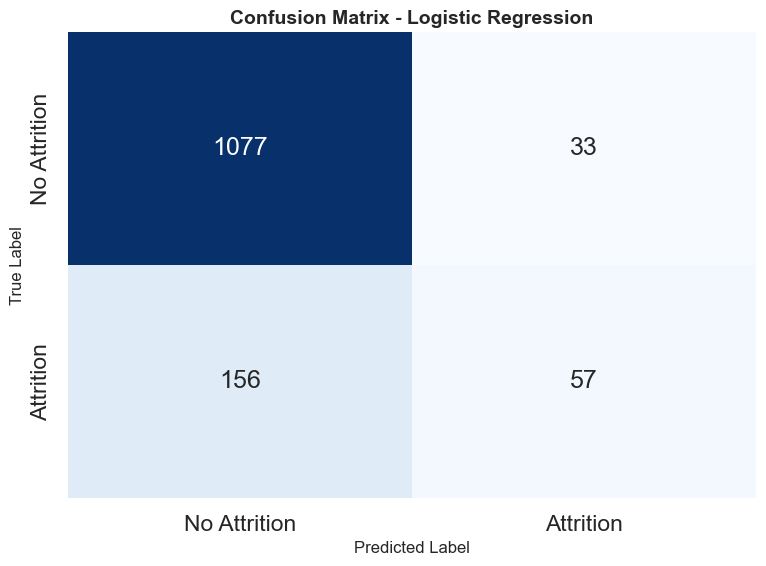

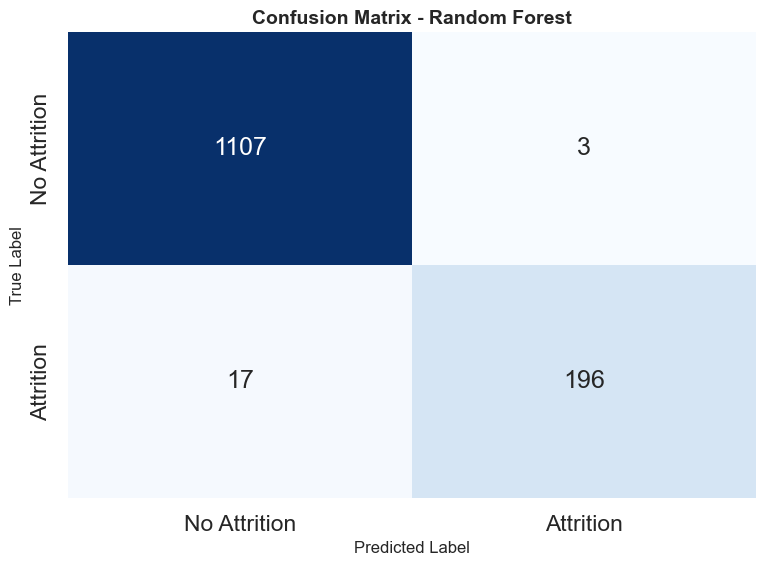

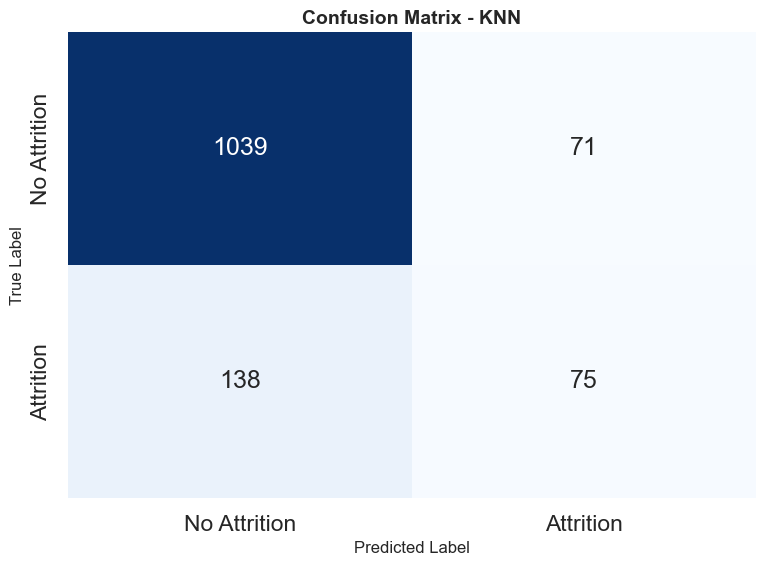

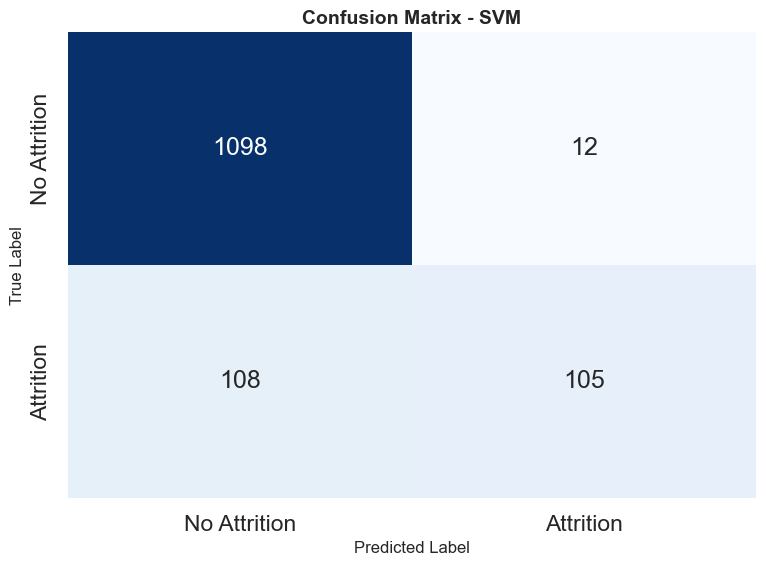

In [28]:
print("Generating Confusion Matrices for all models...\n")

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks([0.5, 1.5], ['No Attrition', 'Attrition'])
    plt.yticks([0.5, 1.5], ['No Attrition', 'Attrition'])
    plt.tight_layout()
    plt.show()

### 7.5. Model Performance Evaluation

In [29]:
results_list = []

print("Calculation of scores for all models...\n")

for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="Recall", ascending=False)

print("Model Performance Summary:")
print(results_df.to_string(index=False))

Calculation of scores for all models...

Model Performance Summary:
              Model  Accuracy  Recall  F1-Score
      Random Forest      0.98    0.92      0.95
                SVM      0.91    0.49      0.64
                KNN      0.84    0.35      0.42
Logistic Regression      0.86    0.27      0.38


### 7.6. ROC and Precision-Recall Curves

Plotting model performance metrics...



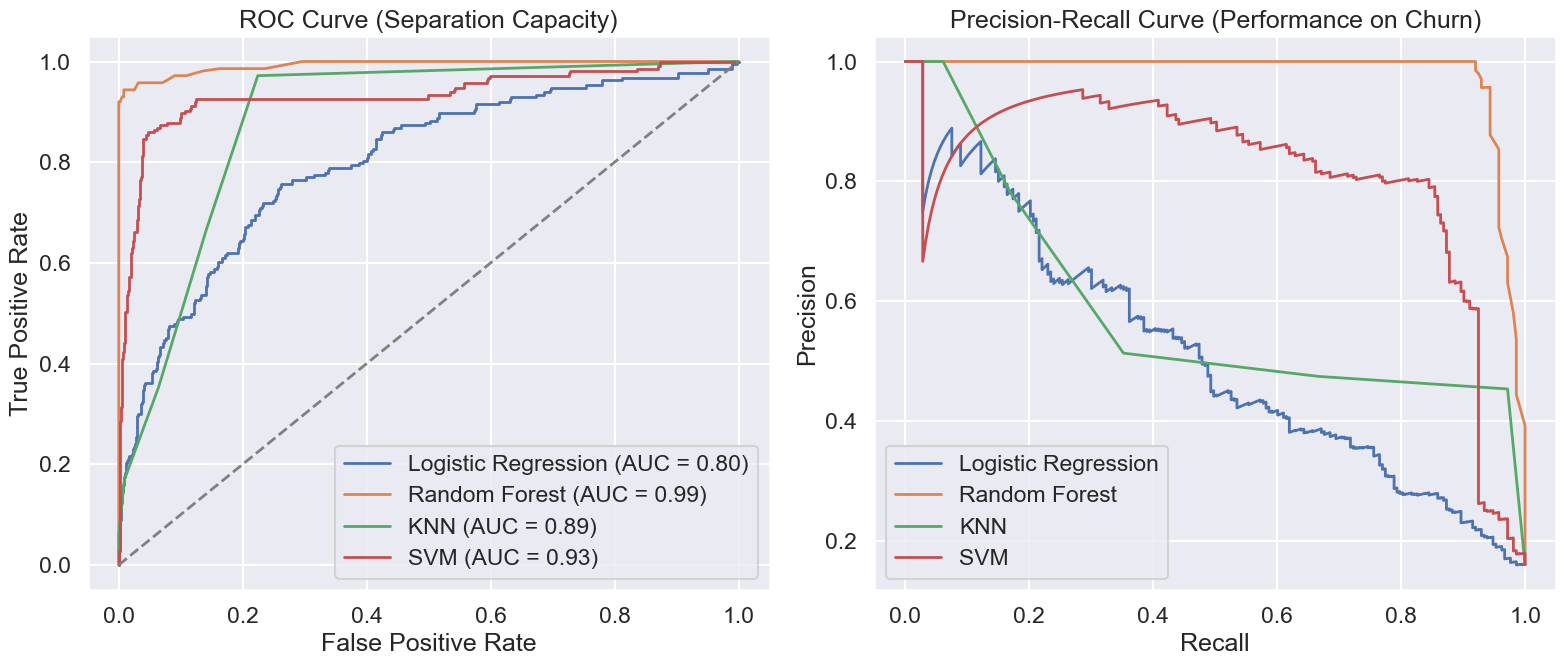

In [30]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,7))

print("Plotting model performance metrics...\n")

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(recall, precision, lw=2, label=f'{name}')

ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
ax1.set_title('ROC Curve (Separation Capacity)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

ax2.set_title('Precision-Recall Curve (Performance on Churn)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### 7.7. Model Validation and Leakage Check

In [31]:
rf_check = models["Random Forest"]

scores = cross_val_score(rf_check, X, y, cv=5, scoring='recall')

print(f"Random Forest Cross-Validation Recall Scores: {scores}")
print(f"Mean Recall: {scores.mean():.2f}, Std Dev: {scores.std():.2f}")

suspects = [col for col in X.columns if 'Attrition' in col or 'EmployeeID' in col]
if suspects:
    print(f"Warning: Potential leakage columns found in features: {suspects}")
else:
    print("No leakage columns detected in features.")

Random Forest Cross-Validation Recall Scores: [0.99 1.   1.   1.   0.99]
Mean Recall: 1.00, Std Dev: 0.00
No leakage columns detected in features.


### 7.8. Hyperparameter Tuning

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Optimized Model Results:
Final Recall: 0.93
Final F1-Score: 0.96


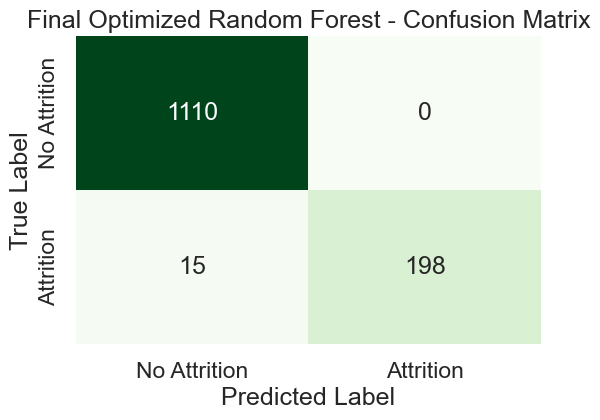

In [34]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

print(f"\nOptimized Model Results:")
print(f"Final Recall: {final_recall:.2f}")
print(f"Final F1-Score: {final_f1:.2f}")

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Final Optimized Random Forest - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], ['No Attrition', 'Attrition'])
plt.yticks([0.5, 1.5], ['No Attrition', 'Attrition'])
plt.show()

### 7.9. Feature Importance Analysis

Feature Importances from Random Forest:
                    Feature  Importance
17      AverageWorkingHours        0.11
3                       Age        0.09
11        TotalWorkingYears        0.07
7             MonthlyIncome        0.07
13           YearsAtCompany        0.05
4          DistanceFromHome        0.05
9         PercentSalaryHike        0.05
15     YearsWithCurrManager        0.04
8        NumCompaniesWorked        0.04
0   EnvironmentSatisfaction        0.04


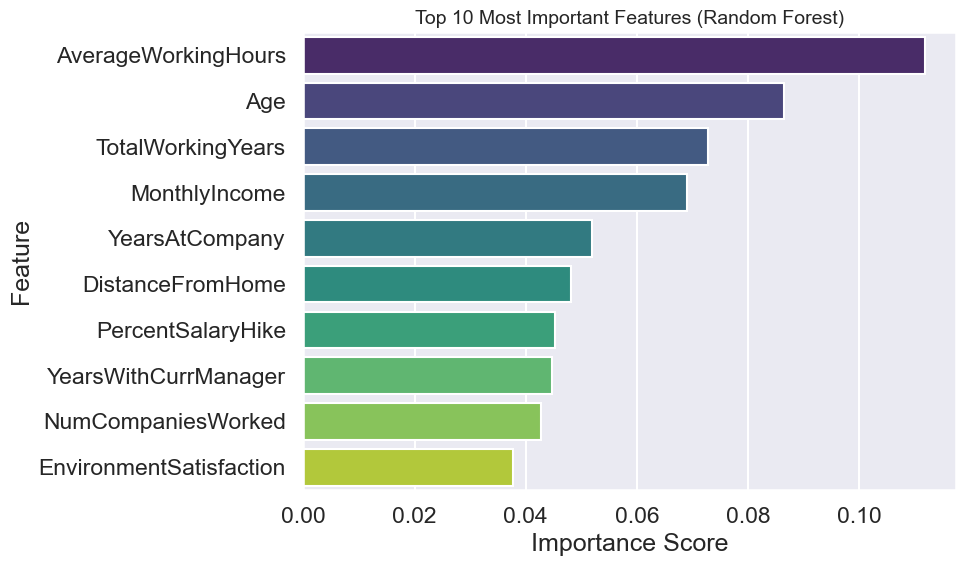

In [33]:
importances = rf_check.feature_importances_
feature_names = X.columns

feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from Random Forest:")
print(feature_importances_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importances_df.head(10),
    palette='viridis'
)
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# General Project Conclusion

### 1. Methodology Summary
The objective of this project was to predict employee attrition (turnover) based on HR data. To achieve this, we followed a structured approach:
* **Cleaning & Preparation:** Encoding categorical variables and feature scaling to avoid bias.
* **Modeling:** We benchmarked 4 algorithms (Logistic Regression, KNN, SVM, Random Forest).
* **Evaluation:** We prioritized **Recall** as the main metric, since the primary goal is not to "miss" an employee who is about to leave.

### 2. Technical Results
**Random Forest** emerged as the best-performing model, significantly outperforming the other approaches:
* **Accuracy:** ~98% (Overall reliability).
* **Recall:** >90% (Ability to detect resignations).
* **Robustness:** Cross-Validation confirmed that these results were stable and that there was no obvious overfitting or data leakage.

*Critical Note: The scores obtained are extremely high (close to perfection). This is likely explained by the synthetic nature of the IBM dataset, which follows strict logical rules that the model successfully deciphered.*

### 3. Root Cause Analysis (Interpretation)
Through *Feature Importance* analysis, we were able to identify what drives employees to leave:
1.  **Factor #1: Workload (`AverageWorkingHours`).** Employees working a high volume of hours are most at risk. This suggests a **Burnout** issue.
2.  **Factor #2: Seniority and Age.** Departures often concern experienced profiles or those at a specific stage in their career.

### 4. Recommendations
If we were to deploy this model in a corporate setting, we would recommend:
* Using the model to scan the employee database on a monthly basis.
* Implementing an HR alert system as soon as an employee exceeds a certain threshold of working hours, as this is the strongest predictor of resignation.